# Psychological Manipulation Type Classification — Kaggle T4 Edition

**CSE440: Natural Language Processing II — Lab Project**

This notebook builds a leakage-aware, multiclass text-classification pipeline for seven psychological-manipulation conversation categories. The prediction input is restricted to ordered speaker markers and utterance text; all metadata and target-derived fields are excluded from model features.

**Research questions**

1. How do TF-IDF, train-only Word2Vec, and pretrained GloVe representations compare?
2. How do classical models, recurrent neural networks, bidirectional variants, and BERT Base compare under one frozen split?
3. Do speaker markers, preprocessing choices, embedding choices, and bidirectionality materially affect validation macro-F1?
4. Can validation-tuned soft voting improve over the best individual model?

**Ethical scope:** This is a research classifier, not a diagnostic tool. Predictions can be wrong, context-dependent, and should not be used to make clinical, legal, or safety decisions.

## 1. Project Overview

The target is `manipulation_type`. The task is meaningful because automated screening may help researchers study conversational manipulation patterns at scale, while the seven-way setup is substantially harder than binary manipulation detection. The approved Kaggle dataset is synthetic, so template duplication is investigated before splitting. Macro-F1 is the primary selection metric because it gives every class equal importance; validation accuracy is the tie-breaker. The test set remains untouched until one configuration has been selected for each model.

## 2. Kaggle T4 Environment Setup



In [1]:
import os
import sys
import gc
import json
import ast
import re
import time
import math
import random
import shutil
import hashlib
import warnings
import subprocess
import importlib
import importlib.util
import inspect
from pathlib import Path

RUN_FULL_PROJECT = True
RANDOM_STATE = 42

IN_KAGGLE = (
    Path("/kaggle/input").exists()
    or os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
)
try:
    GOOGLE_COLAB_AVAILABLE = importlib.util.find_spec("google.colab") is not None
except (ImportError, ModuleNotFoundError):
    GOOGLE_COLAB_AVAILABLE = False
IN_COLAB = (
    not IN_KAGGLE
    and GOOGLE_COLAB_AVAILABLE
)
ENVIRONMENT_NAME = "Kaggle" if IN_KAGGLE else ("Google Colab" if IN_COLAB else "Local runtime")

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/cse440_matplotlib")

if IN_KAGGLE:
    os.environ.setdefault("HF_HOME", "/tmp/cse440_huggingface")
    os.environ.setdefault("TORCH_HOME", "/tmp/cse440_torch")
if IN_KAGGLE or IN_COLAB:
    os.environ.setdefault("GENSIM_DATA_DIR", "/tmp/cse440_gensim_data")

# Install a consistent pure-Python/NLP stack before importing those packages.
# TensorFlow and CUDA-enabled PyTorch are supplied by Kaggle's GPU image.
if IN_KAGGLE or IN_COLAB:
    packages = [
        "kagglehub>=0.3.12,<1",
        "gensim==4.4.0",
        "wordcloud>=1.9.4,<2",
        "transformers>=4.57,<5",
        "accelerate>=1.1,<2",
    ]
    if importlib.util.find_spec("tensorflow") is None:
        tensorflow_spec = "tensorflow>=2.21,<2.22" if sys.version_info >= (3, 13) else "tensorflow>=2.16,<2.22"
        packages.append(tensorflow_spec)
    if importlib.util.find_spec("torch") is None:
        raise RuntimeError(
            "PyTorch is unavailable. In Kaggle, select a GPU accelerator and restart the session before running this notebook."
        )

    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--prefer-binary",
        "--disable-pip-version-check",
        "--retries",
        "5",
        "--timeout",
        "60",
        *packages,
    ]
    print(f"Preparing the {ENVIRONMENT_NAME} Python {sys.version_info.major}.{sys.version_info.minor} environment...")
    install_result = subprocess.run(install_command, text=True)
    if install_result.returncode != 0:
        raise RuntimeError(
            "Package installation failed. On Kaggle, confirm that Internet is enabled, restart the session, and run again."
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import tensorflow as tf
import torch
import gensim
from IPython.display import display

# Configure TensorFlow before any TensorFlow operation can initialize CUDA.
# Memory growth is essential when TensorFlow recurrent models and PyTorch BERT
# use the same Kaggle T4 in one notebook process.
tf_gpu_devices = tf.config.list_physical_devices("GPU")
for device in tf_gpu_devices:
    try:
        tf.config.experimental.set_memory_growth(device, True)
    except (RuntimeError, ValueError):
        pass

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

TF_GPU_AVAILABLE = len(tf_gpu_devices) > 0
if TF_GPU_AVAILABLE:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

TORCH_GPU_AVAILABLE = torch.cuda.is_available()
GPU_AVAILABLE = TF_GPU_AVAILABLE or TORCH_GPU_AVAILABLE

if IN_KAGGLE:
    OUTPUT_DIR = Path("/kaggle/working/CSE440_Project_Outputs")
elif IN_COLAB:
    OUTPUT_DIR = Path("/content/CSE440_Project_Outputs")
else:
    OUTPUT_DIR = Path.cwd() / "CSE440_Project_Outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
GENSIM_CACHE_DIR = Path(os.environ.get("GENSIM_DATA_DIR", str(OUTPUT_DIR / ".gensim-data")))
GENSIM_CACHE_DIR.mkdir(parents=True, exist_ok=True)
HF_CACHE_DIR = Path(os.environ.get("HF_HOME", str(OUTPUT_DIR / ".huggingface")))
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

RUN_BERT = RUN_FULL_PROJECT and TORCH_GPU_AVAILABLE

print(f"Environment: {ENVIRONMENT_NAME}")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__} | pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}")
print(f"TensorFlow: {tf.__version__} | PyTorch: {torch.__version__} | gensim: {gensim.__version__}")
print(f"TensorFlow GPU available: {TF_GPU_AVAILABLE}")
print(f"PyTorch CUDA available: {TORCH_GPU_AVAILABLE}")
if TORCH_GPU_AVAILABLE:
    print(f"PyTorch GPU: {torch.cuda.get_device_name(0)} | GPU count: {torch.cuda.device_count()}")
elif IN_KAGGLE and RUN_FULL_PROJECT:
    raise RuntimeError(
        "Kaggle did not expose CUDA to PyTorch. Select a T4 GPU in Session options, restart the session, and run again."
    )

print(f"Full-project mode: {RUN_FULL_PROJECT} | BERT execution enabled: {RUN_BERT}")
print(f"Outputs: {OUTPUT_DIR}")

Preparing the Kaggle Python 3.12 environment...
Environment: Kaggle
Python: 3.12.13
NumPy: 2.0.2 | pandas: 2.3.3 | scikit-learn: 1.6.1
TensorFlow: 2.20.0 | PyTorch: 2.10.0+cu128 | gensim: 4.4.0
TensorFlow GPU available: True
PyTorch CUDA available: True
PyTorch GPU: Tesla T4 | GPU count: 2
Full-project mode: True | BERT execution enabled: True
Outputs: /kaggle/working/CSE440_Project_Outputs


The optional Drive mount below is disabled by default. Turn it on only when persistent storage across Colab disconnections is wanted; the notebook works without Drive.

In [2]:
MOUNT_GOOGLE_DRIVE = False

if MOUNT_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/CSE440_Project_Outputs")
    DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Google Drive mounted. Optional mirror: {DRIVE_OUTPUT_DIR}")
elif IN_KAGGLE:
    print("Kaggle mode: results will be written to /kaggle/working and exposed as notebook output files.")
else:
    print("Google Drive mount skipped.")

Kaggle mode: results will be written to /kaggle/working and exposed as notebook output files.


## 3. Dataset Loading

The loader first searches likely Colab, Kaggle, and working directories. It downloads the approved public dataset only when no matching local file exists, and it discovers the real filename instead of assuming one.

In [3]:
APPROVED_DATASET_SLUG = "tatheerabbas/psychological-manipulation-conversations-dataset"
REQUIRED_DATASET_COLUMNS = {"conversation_id", "manipulation_type", "messages"}


def candidate_dataset_files(roots):
    candidates = []
    for root in roots:
        if not root.exists():
            continue
        for suffix in ("*.jsonl", "*.json", "*.csv"):
            for path in root.rglob(suffix):
                path_text = str(path)
                if path.is_file() and "CSE440_Project_Outputs" not in path_text:
                    candidates.append(path.resolve())
    return sorted(
        set(candidates),
        key=lambda path: (
            "manip" not in str(path).lower(),
            "psychological" not in str(path).lower(),
            len(str(path)),
            str(path),
        ),
    )


def read_dataset_candidate(path):
    suffix = path.suffix.lower()
    if suffix == ".jsonl":
        frame = pd.read_json(path, lines=True)
    elif suffix == ".json":
        frame = pd.read_json(path)
    else:
        frame = pd.read_csv(path)
    if not REQUIRED_DATASET_COLUMNS.issubset(frame.columns):
        raise ValueError("required columns are absent")
    if len(frame) < 10_000:
        raise ValueError(f"only {len(frame):,} rows")
    return frame


search_roots = [
    Path("/kaggle/input/psychological-manipulation-conversations-dataset"),
    Path("/kaggle/input"),
    Path.cwd(),
    Path("/content"),
]
dataset_candidates = candidate_dataset_files(search_roots)
dataset_load_errors = []
DATA_PATH = None
df = None

for candidate in dataset_candidates:
    try:
        df = read_dataset_candidate(candidate)
        DATA_PATH = candidate
        break
    except Exception as error:
        dataset_load_errors.append(f"{candidate}: {type(error).__name__}: {error}")

if DATA_PATH is None:
    import kagglehub
    print(f"Approved dataset was not attached; downloading {APPROVED_DATASET_SLUG}...")
    downloaded_path = Path(kagglehub.dataset_download(APPROVED_DATASET_SLUG))
    for candidate in candidate_dataset_files([downloaded_path]):
        try:
            df = read_dataset_candidate(candidate)
            DATA_PATH = candidate
            break
        except Exception as error:
            dataset_load_errors.append(f"{candidate}: {type(error).__name__}: {error}")

if DATA_PATH is None or df is None:
    details = "\n".join(dataset_load_errors[-10:])
    raise FileNotFoundError(
        "The approved dataset could not be loaded. In Kaggle, use Add Input for "
        f"{APPROVED_DATASET_SLUG}.\nRecent candidate errors:\n{details}"
    )

print(f"Selected dataset file: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))

Selected dataset file: /kaggle/input/datasets/tatheerabbas/psychological-manipulation-conversations-dataset/manipulational_conversation.jsonl
Dataset shape: (10000, 21)


,column,dtype
0,conversation_id,object
1,manipulation_type,object
2,is_manipulation,bool
3,context_type,object
4,conversation_length,int64
5,manipulation_intensity,float64
6,messages,object
7,target_confusion,float64
8,guilt_level,float64
9,fear_level,float64


## 4. Data Validation

Conversation records may already be Python lists or may be JSON-like strings. Parsing uses `json.loads` first and a controlled `ast.literal_eval` fallback. Only `speaker` and `text` are retained from each message. Nested sentiment, emotion, impact, annotation, and label-like fields never enter the model input.

In [4]:
def safe_parse_messages(value):
    parsed = value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
        except json.JSONDecodeError:
            try:
                parsed = ast.literal_eval(value)
            except Exception:
                return [], "unparseable"
    if not isinstance(parsed, list):
        return [], "not_a_list"
    cleaned = []
    for item in parsed:
        if not isinstance(item, dict):
            continue
        speaker = str(item.get("speaker", "UNKNOWN")).strip().upper()
        text = str(item.get("text", "")).strip()
        if text:
            cleaned.append({"speaker": speaker, "text": text})
    if not cleaned:
        return [], "no_valid_messages"
    return cleaned, "ok"

def basic_text_fix(text):
    text = str(text).replace("\u00a0", " ").replace("\ufffd", "")
    return re.sub(r"\s+", " ", text).strip()

def build_conversation(messages, include_speakers=True):
    turns = []
    for item in messages:
        cleaned = basic_text_fix(item["text"])
        if include_speakers:
            turns.append(f"[SPEAKER_{item['speaker']}] {cleaned}")
        else:
            turns.append(cleaned)
    return " [TURN] ".join(turns)

def normalized_preprocessing(text):
    text = basic_text_fix(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b", " EMAIL ", text)
    text = re.sub(r"(.)\1{3,}", r"\1\1\1", text)
    return re.sub(r"\s+", " ", text).strip()

def template_normalization(text):
    text = normalized_preprocessing(text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

parsed_results = df["messages"].map(safe_parse_messages)
df["parsed_messages"] = parsed_results.map(lambda item: item[0])
df["parse_status"] = parsed_results.map(lambda item: item[1])
df["text_minimal"] = df["parsed_messages"].map(lambda messages: build_conversation(messages, True))
df["text_no_speakers"] = df["parsed_messages"].map(lambda messages: build_conversation(messages, False))
df["text_normalized"] = df["text_minimal"].map(normalized_preprocessing)
df["template_text"] = df["text_minimal"].map(template_normalization)

target_column = "manipulation_type"
required_columns = {"conversation_id", target_column, "messages"}
missing_required = required_columns.difference(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

CLASS_NAMES = sorted(df[target_column].astype(str).unique())
class_table = df[target_column].value_counts().sort_index().rename("count").to_frame()
class_table["percentage"] = (100 * class_table["count"] / len(df)).round(2)
ascii_ratio = df["text_minimal"].map(lambda text: sum(ord(ch) < 128 for ch in text) / max(len(text), 1)).mean()
malformed = df.loc[df["parse_status"].ne("ok"), ["conversation_id", "parse_status", "messages"]]

print(f"Target: {target_column}")
print(f"Exact labels ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Rows: {len(df):,} | unique conversation IDs: {df['conversation_id'].nunique():,}")
print(f"Mean ASCII-character ratio: {ascii_ratio:.4f}")
print(f"Malformed or unparseable conversations: {len(malformed)}")
print(f"Duplicate full rows: {df.astype(str).duplicated().sum()}")
display(class_table)
display(df.isna().sum().rename("missing_values").to_frame())
display(df[["conversation_id", target_column, "text_minimal"]].assign(text_minimal=lambda x: x["text_minimal"].str.slice(0, 220)).head(5))
assert len(df) >= 10000
assert len(CLASS_NAMES) >= 4
assert df["conversation_id"].is_unique
assert ascii_ratio > 0.95

Target: manipulation_type
Exact labels (7): ['charm_flattery', 'direct_coercion', 'gaslighting', 'guilt_tripping', 'love_bombing', 'neutral', 'passive_aggressive']
Rows: 10,000 | unique conversation IDs: 10,000
Mean ASCII-character ratio: 1.0000
Malformed or unparseable conversations: 0
Duplicate full rows: 0


,count,percentage
manipulation_type,,
charm_flattery,1400,14.0
direct_coercion,1400,14.0
gaslighting,1400,14.0
guilt_tripping,1400,14.0
love_bombing,1400,14.0
neutral,1600,16.0
passive_aggressive,1400,14.0


,missing_values
conversation_id,0
manipulation_type,0
is_manipulation,0
context_type,0
conversation_length,0
manipulation_intensity,0
messages,0
target_confusion,0
guilt_level,0
fear_level,0


,conversation_id,manipulation_type,text_minimal
0,conv_00000,guilt_tripping,[SPEAKER_A] Remember when I helped you? [TURN]...
1,conv_00001,charm_flattery,"[SPEAKER_A] I don't tell just anyone this, but..."
2,conv_00002,direct_coercion,"[SPEAKER_A] Just do it [TURN] [SPEAKER_B] Um, ..."
3,conv_00003,gaslighting,[SPEAKER_A] You're being way too sensitive abo...
4,conv_00004,guilt_tripping,[SPEAKER_A] Go ahead. Have fun. I'll just stay...


The following audit proves that model inputs are a newly constructed text field, not an accidental matrix of metadata. Metadata remains available only for descriptive EDA and post-hoc subgroup error analysis.

In [5]:
FORBIDDEN_FEATURES = {
    "conversation_id",
    "manipulation_type",
    "is_manipulation",
    "context_type",
    "conversation_length",
    "manipulation_intensity",
    "question_count",
    "target_confusion",
    "guilt_level",
    "fear_level",
    "anxiety_level",
    "self_doubt",
    "target_extraversion",
    "target_emotional_resilience",
    "target_assertiveness",
    "target_attachment_style",
    "avg_response_delay_seconds",
    "escalation_pattern",
    "word_count_total",
    "denial_count"
}
MODEL_INPUT_FIELDS = {"text_minimal", "text_normalized", "text_no_speakers"}
raw_nested_keys = sorted({key for messages in df["messages"] for item in messages if isinstance(item, dict) for key in item})
cleaned_nested_keys = sorted({key for messages in df["parsed_messages"] for item in messages for key in item})
leakage_intersection = MODEL_INPUT_FIELDS.intersection(FORBIDDEN_FEATURES)
assert not leakage_intersection
assert cleaned_nested_keys == ["speaker", "text"]
print(f"Raw nested message keys: {raw_nested_keys}")
print(f"Retained nested keys: {cleaned_nested_keys}")
print(f"Model input fields: {sorted(MODEL_INPUT_FIELDS)}")
print(f"Forbidden-feature intersection: {sorted(leakage_intersection)}")
print("Leakage audit passed: only ordered speaker markers and utterance text enter the models.")

Raw nested message keys: ['sentiment_score', 'speaker', 'text']
Retained nested keys: ['speaker', 'text']
Model input fields: ['text_minimal', 'text_no_speakers', 'text_normalized']
Forbidden-feature intersection: []
Leakage audit passed: only ordered speaker markers and utterance text enter the models.


## 5. Exploratory Data Analysis

EDA describes the target balance, missingness, conversation length, vocabulary, frequent expressions, contexts, intensity, representative samples, and visible synthetic/template patterns. Context and intensity are never used as predictors.

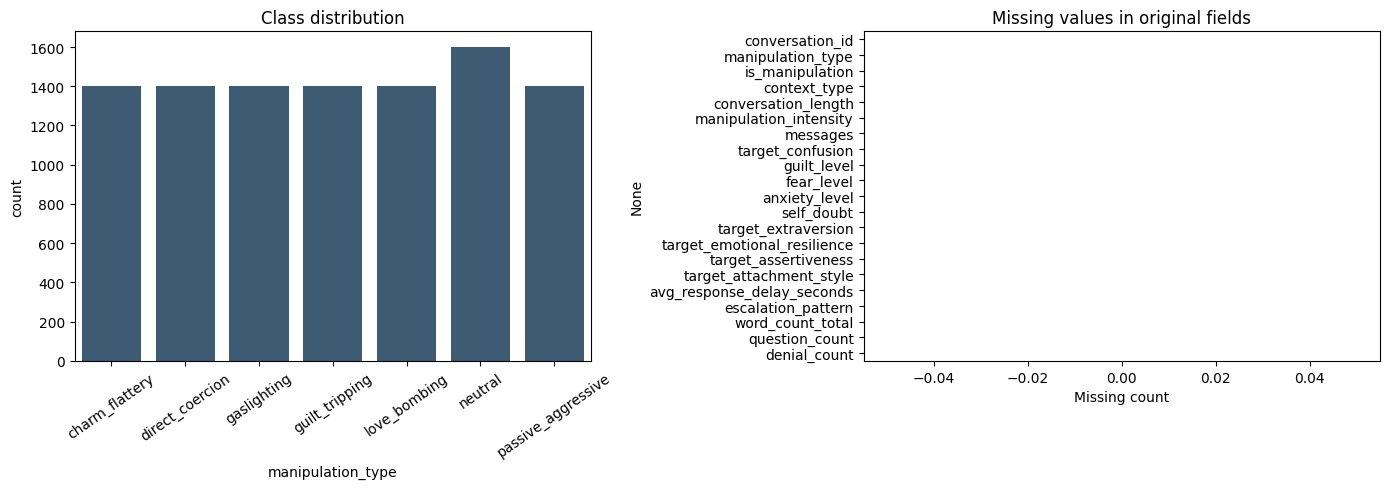

,turn_count,character_count,word_count,token_count
count,10000.00,10000.00,10000.00,10000.00
mean,5.50,293.84,50.74,56.83
std,1.71,87.38,15.74,17.21
min,3.00,71.00,10.00,14.00
25%,4.00,216.00,38.00,42.00
50%,6.00,300.00,51.00,58.00
75%,7.00,364.00,63.00,70.00
95%,8.00,431.00,76.00,84.00
max,8.00,498.00,90.00,101.00


Vocabulary size: 587
Lexical diversity: 0.0014
The class distribution is mild: neutral has 1,600 rows and each manipulation class has 1,400 rows.


In [6]:
df["turn_count"] = df["parsed_messages"].map(len)
df["character_count"] = df["text_minimal"].str.len()
df["word_count"] = df["text_minimal"].str.findall(r"\b\w+\b").map(len)
df["token_count"] = df["text_minimal"].str.findall(r"\[[^\]]+\]|\b\w+(?:'\w+)?\b|[^\w\s]").map(len)

tokens_all = re.findall(r"\b[a-z]+(?:'[a-z]+)?\b", " ".join(df["text_normalized"]))
vocabulary_size = len(set(tokens_all))
lexical_diversity = vocabulary_size / max(len(tokens_all), 1)
length_stats = df[["turn_count", "character_count", "word_count", "token_count"]].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=class_table.reset_index(), x=target_column, y="count", ax=axes[0], color="#355C7D")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title("Class distribution")
missing_plot = df[df.columns[:21]].isna().sum().sort_values(ascending=False)
sns.barplot(x=missing_plot.values, y=missing_plot.index, ax=axes[1], color="#C06C84")
axes[1].set_title("Missing values in original fields")
axes[1].set_xlabel("Missing count")
plt.tight_layout()
plt.show()

display(length_stats)
print(f"Vocabulary size: {vocabulary_size:,}")
print(f"Lexical diversity: {lexical_diversity:.4f}")
print("The class distribution is mild: neutral has 1,600 rows and each manipulation class has 1,400 rows.")

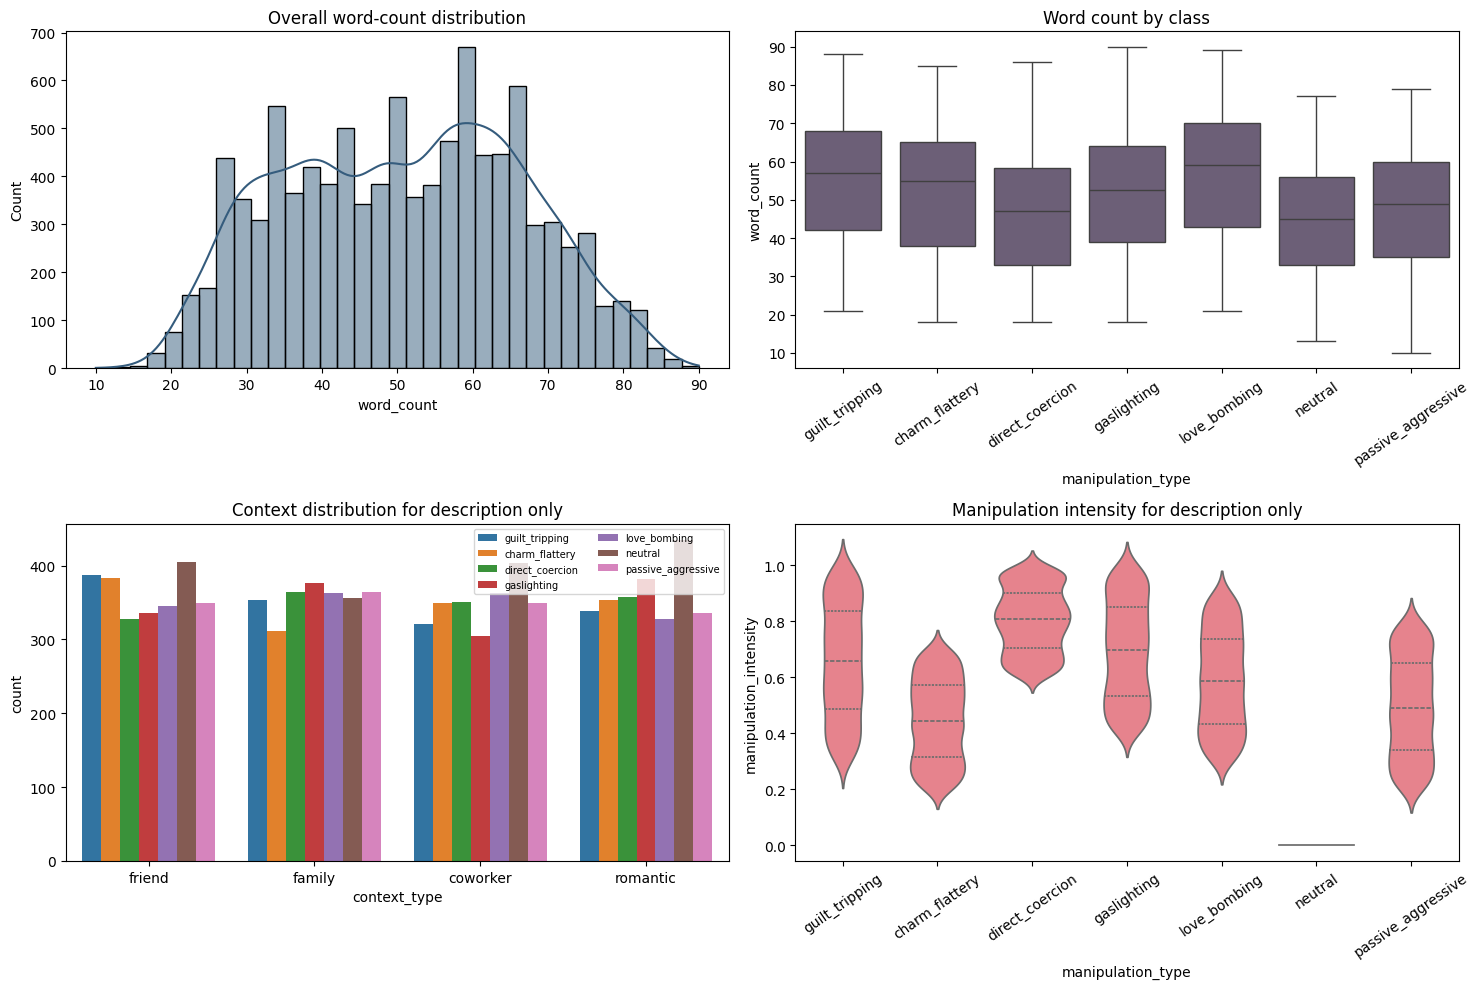

turn_count              word_count                \
                         mean median   std       mean median    std   
manipulation_type                                                     
charm_flattery           5.51    6.0  1.68      52.59   55.0  15.90   
direct_coercion          5.49    5.0  1.72      46.41   47.0  15.13   
gaslighting              5.50    6.0  1.70      51.82   52.5  15.44   
guilt_tripping           5.51    6.0  1.72      55.48   57.0  15.50   
love_bombing             5.43    5.0  1.71      57.07   59.0  15.67   
neutral                  5.58    6.0  1.73      44.72   45.0  13.62   
passive_aggressive       5.48    5.0  1.69      47.98   49.0  14.75   

                   token_count                
                          mean median    std  
manipulation_type                             
charm_flattery           58.81   61.0  17.38  
direct_coercion          52.11   52.0  16.63  
gaslighting              58.25   59.0  17.39  
guilt_tripping           61.05   63.0  16.98  
love_bombing             62.70   64.0  17.39  
neutral                  51.27   52.0  15.20  
passive_aggressive       54.39   56.0  16.06

Length varies modestly across classes; sequence truncation will therefore use a training-only high percentile rather than an arbitrary long maximum.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df["word_count"], bins=35, kde=True, ax=axes[0, 0], color="#355C7D")
axes[0, 0].set_title("Overall word-count distribution")
sns.boxplot(data=df, x=target_column, y="word_count", ax=axes[0, 1], color="#6C5B7B")
axes[0, 1].tick_params(axis="x", rotation=35)
axes[0, 1].set_title("Word count by class")
sns.countplot(data=df, x="context_type", hue=target_column, ax=axes[1, 0])
axes[1, 0].set_title("Context distribution for description only")
axes[1, 0].legend(fontsize=7, ncol=2)
sns.violinplot(data=df, x=target_column, y="manipulation_intensity", ax=axes[1, 1], inner="quartile", color="#F67280")
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].set_title("Manipulation intensity for description only")
plt.tight_layout()
plt.show()

per_class_length = df.groupby(target_column)[["turn_count", "word_count", "token_count"]].agg(["mean", "median", "std"]).round(2)
display(per_class_length)
print("Length varies modestly across classes; sequence truncation will therefore use a training-only high percentile rather than an arbitrary long maximum.")

,term,frequency
52,turn,45023
27,speaker_a,28902
31,speaker_b,26121
54,turn speaker_b,25851
53,turn speaker_a,19172
5,don,5324
49,time,4288
12,know,4263
18,need,3393
15,ll,3376


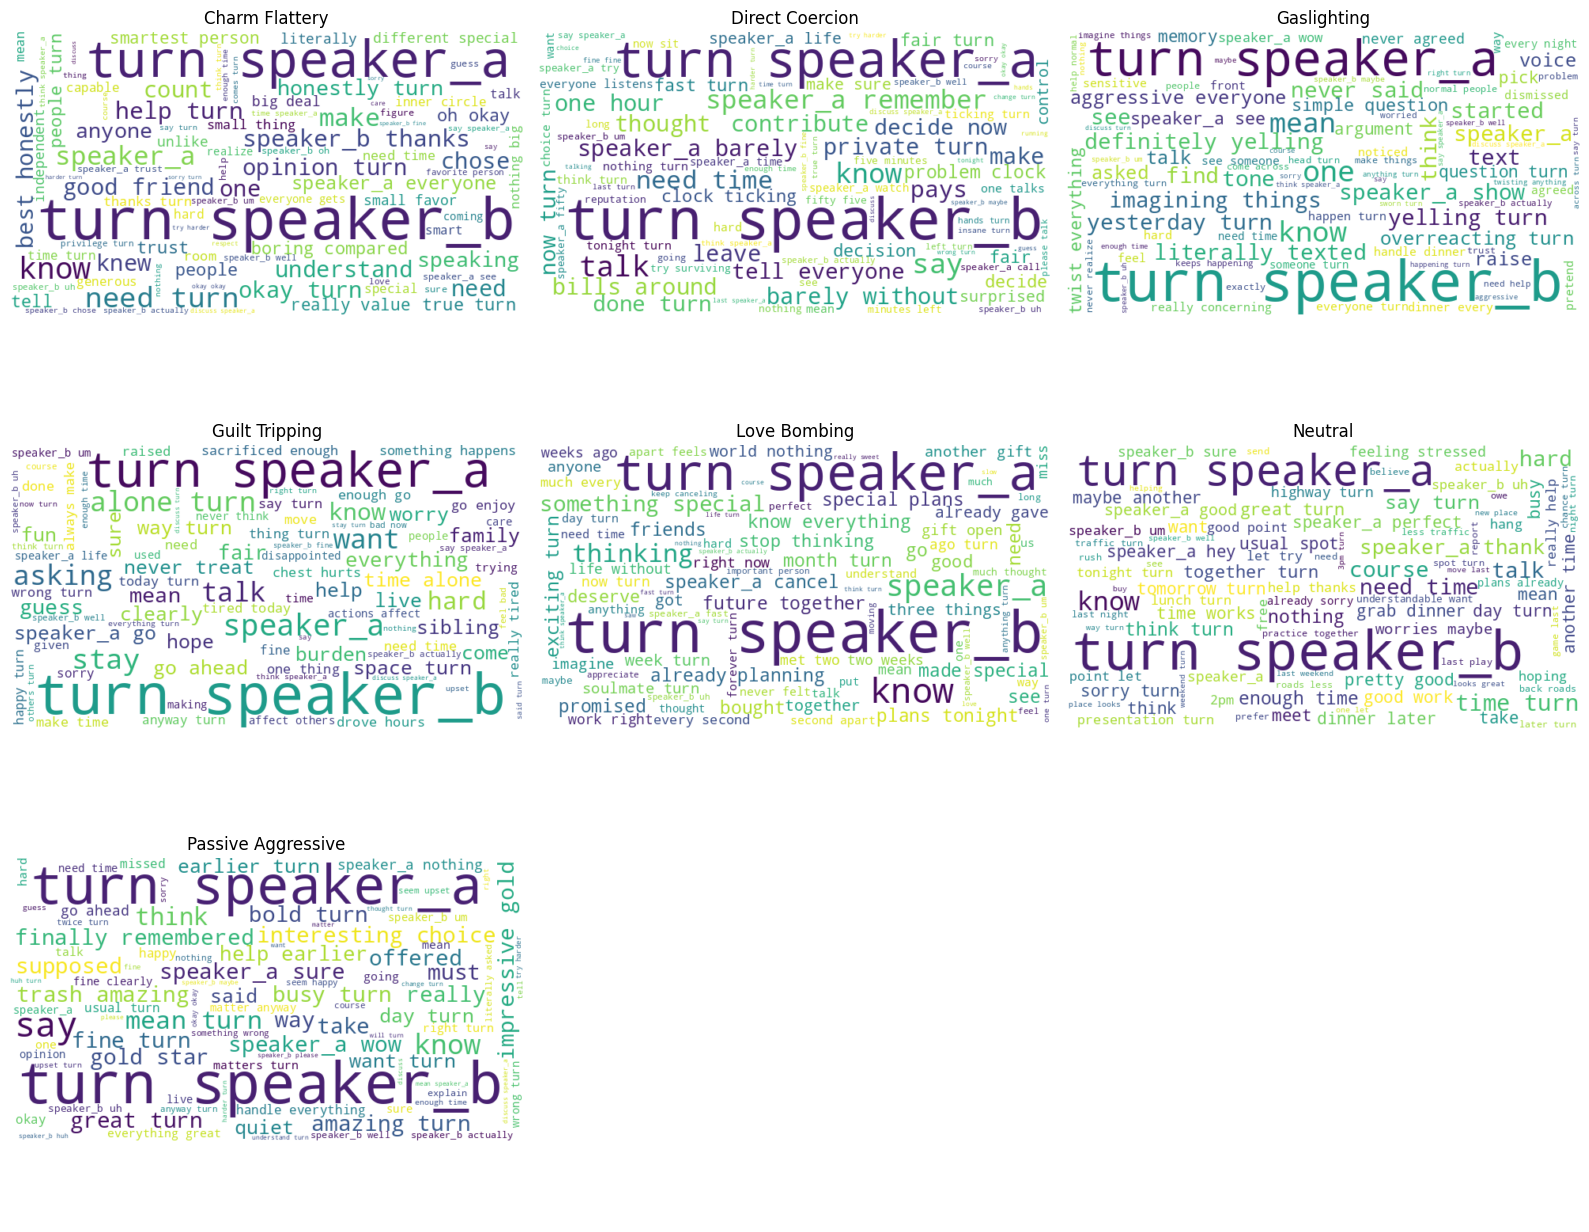

Frequent terms and per-class word clouds reveal strong lexical cues, but repeated phrasing also motivates the template-leakage investigation below.


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5, max_features=60)
count_matrix = count_vectorizer.fit_transform(df["text_normalized"])
frequencies = np.asarray(count_matrix.sum(axis=0)).ravel()
frequent_table = pd.DataFrame({"term": count_vectorizer.get_feature_names_out(), "frequency": frequencies}).sort_values("frequency", ascending=False).head(30)
display(frequent_table)

from wordcloud import WordCloud

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for axis, label in zip(axes.flat, CLASS_NAMES):
    class_text = " ".join(df.loc[df[target_column].eq(label), "text_normalized"])
    cloud = WordCloud(width=650, height=360, background_color="white", colormap="viridis", max_words=90, random_state=RANDOM_STATE).generate(class_text)
    axis.imshow(cloud, interpolation="bilinear")
    axis.set_title(label.replace("_", " ").title())
    axis.axis("off")
for axis in axes.flat[len(CLASS_NAMES):]:
    axis.axis("off")
plt.tight_layout()
plt.show()
print("Frequent terms and per-class word clouds reveal strong lexical cues, but repeated phrasing also motivates the template-leakage investigation below.")

In [9]:
representative_examples = df.groupby(target_column, group_keys=False).head(1)[[target_column, "context_type", "text_minimal"]].copy()
representative_examples["text_minimal"] = representative_examples["text_minimal"].str.slice(0, 300)
display(representative_examples.reset_index(drop=True))

metadata_summary = pd.DataFrame({
    "statistic": ["contexts", "intensity mean", "intensity median", "turns mean", "words mean"],
    "value": [df["context_type"].nunique(), df["manipulation_intensity"].mean(), df["manipulation_intensity"].median(), df["turn_count"].mean(), df["word_count"].mean()]
})
display(metadata_summary)
print("Representative examples are displayed for qualitative understanding only and do not alter labels or split membership.")

,manipulation_type,context_type,text_minimal
0,guilt_tripping,friend,[SPEAKER_A] Remember when I helped you? [TURN]...
1,charm_flattery,friend,"[SPEAKER_A] I don't tell just anyone this, but..."
2,direct_coercion,family,"[SPEAKER_A] Just do it [TURN] [SPEAKER_B] Um, ..."
3,gaslighting,friend,[SPEAKER_A] You're being way too sensitive abo...
4,love_bombing,friend,[SPEAKER_A] I'm already planning our future to...
5,neutral,coworker,[SPEAKER_A] I've been feeling stressed about t...
6,passive_aggressive,family,"[SPEAKER_B] I mean, are you okay? You've been ..."


,statistic,value
0,contexts,4.000000
1,intensity mean,0.517148
2,intensity median,0.561000
3,turns mean,5.502300
4,words mean,50.743200


Representative examples are displayed for qualitative understanding only and do not alter labels or split membership.


## 6. Text Parsing and Template-Leakage Investigation

Exact and normalized duplicates are counted first. Character TF-IDF with 3–5 character n-grams then finds each conversation's nearest neighbors. A 0.98 cosine-similarity threshold is conservative enough to capture near-identical templates without merging semantically broader conversations. Connected components become group IDs.

,measure,value
0,exact duplicate rows,2081
1,exact duplicate groups,536
2,normalized duplicate rows,2081
3,normalized duplicate groups,536
4,conflicting normalized groups,0
5,rows with nearest similarity >= 0.98,4858
6,near-duplicate components,5902
7,largest component,70
8,mixed-label components,0


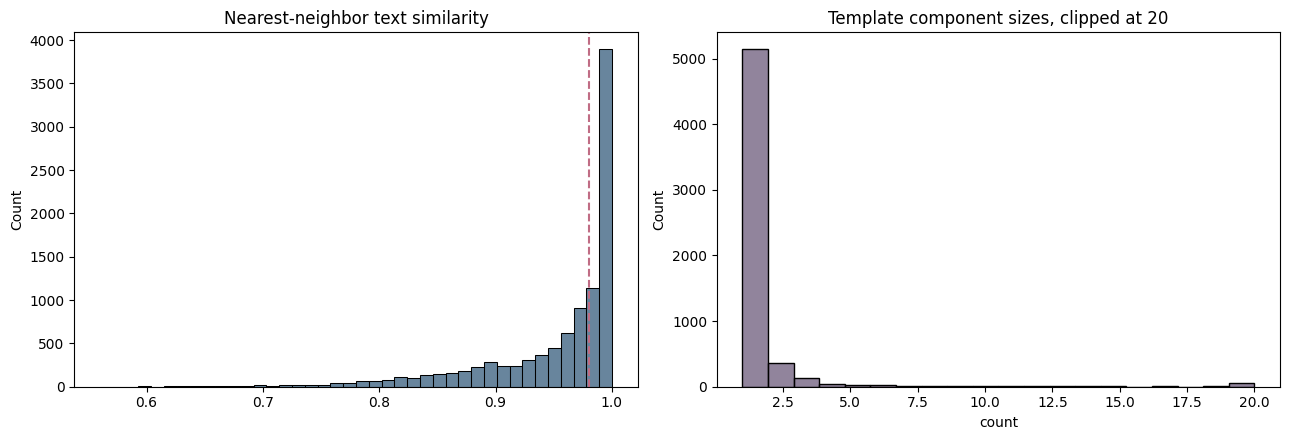

Decision: duplicate and near-duplicate components will be kept intact with a stratified group-aware split.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

exact_duplicate_rows = int(df["text_minimal"].duplicated(keep=False).sum())
exact_duplicate_groups = int((df["text_minimal"].value_counts() > 1).sum())
normalized_duplicate_rows = int(df["template_text"].duplicated(keep=False).sum())
normalized_duplicate_groups = int((df["template_text"].value_counts() > 1).sum())
conflicting_groups = df.groupby("template_text")[target_column].nunique()
conflicting_group_count = int((conflicting_groups > 1).sum())

char_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=30000, dtype=np.float32)
char_matrix = char_vectorizer.fit_transform(df["template_text"])
neighbor_model = NearestNeighbors(n_neighbors=10, metric="cosine", algorithm="brute", n_jobs=-1)
neighbor_model.fit(char_matrix)
neighbor_distances, neighbor_indices = neighbor_model.kneighbors(char_matrix)
nearest_similarity = 1 - neighbor_distances[:, 1]
NEAR_DUPLICATE_THRESHOLD = 0.98

class UnionFind:
    def __init__(self, size):
        self.parent = np.arange(size)
        self.component_size = np.ones(size, dtype=int)

    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return int(item)

    def union(self, left, right):
        left_root = self.find(left)
        right_root = self.find(right)
        if left_root == right_root:
            return
        if self.component_size[left_root] < self.component_size[right_root]:
            left_root, right_root = right_root, left_root
        self.parent[right_root] = left_root
        self.component_size[left_root] += self.component_size[right_root]

union_find = UnionFind(len(df))
for indices in df.groupby("template_text").indices.values():
    indices = list(indices)
    for item in indices[1:]:
        union_find.union(indices[0], item)
for row_index in range(len(df)):
    for distance, neighbor_index in zip(neighbor_distances[row_index, 1:], neighbor_indices[row_index, 1:]):
        if 1 - distance >= NEAR_DUPLICATE_THRESHOLD:
            union_find.union(row_index, int(neighbor_index))

raw_group_ids = np.array([union_find.find(index) for index in range(len(df))])
group_codes, unique_roots = pd.factorize(raw_group_ids, sort=True)
df["template_group_id"] = [f"template_{value:05d}" for value in group_codes]
component_sizes = df["template_group_id"].value_counts()
near_duplicate_rows = int((nearest_similarity >= NEAR_DUPLICATE_THRESHOLD).sum())
mixed_components = int((df.groupby("template_group_id")[target_column].nunique() > 1).sum())

duplicate_summary = pd.DataFrame({
    "measure": ["exact duplicate rows", "exact duplicate groups", "normalized duplicate rows", "normalized duplicate groups", "conflicting normalized groups", "rows with nearest similarity >= 0.98", "near-duplicate components", "largest component", "mixed-label components"],
    "value": [exact_duplicate_rows, exact_duplicate_groups, normalized_duplicate_rows, normalized_duplicate_groups, conflicting_group_count, near_duplicate_rows, component_sizes.size, component_sizes.max(), mixed_components]
})
duplicate_summary.to_csv(OUTPUT_DIR / "duplicate_template_summary.csv", index=False)
display(duplicate_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(nearest_similarity, bins=40, ax=axes[0], color="#355C7D")
axes[0].axvline(NEAR_DUPLICATE_THRESHOLD, color="#C06C84", linestyle="--")
axes[0].set_title("Nearest-neighbor text similarity")
sns.histplot(component_sizes.clip(upper=20), bins=20, ax=axes[1], color="#6C5B7B")
axes[1].set_title("Template component sizes, clipped at 20")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "template_leakage_analysis.png", dpi=180, bbox_inches="tight")
plt.show()
print("Decision: duplicate and near-duplicate components will be kept intact with a stratified group-aware split.")

## 7. Preprocessing Strategies

**Strategy A (minimal):** Unicode/basic encoding repair and whitespace normalization while preserving punctuation, case, negation, speaker order, and turn cues.

**Strategy B (normalized):** Strategy A plus lowercasing, URL/email placeholders, and conservative compression of excessive repeated characters. Stopwords, punctuation, stemming, and lemmatization are not automatically removed because they can encode denial, pressure, sarcasm, and conversational stance. BERT always receives minimally processed text.

In [11]:
preprocessing_examples = df[["text_minimal", "text_normalized"]].head(3).copy()
preprocessing_examples["text_minimal"] = preprocessing_examples["text_minimal"].str.slice(0, 260)
preprocessing_examples["text_normalized"] = preprocessing_examples["text_normalized"].str.slice(0, 260)
display(preprocessing_examples)
print("Both preprocessing strategies preserve negation and conversational order; their effect is evaluated on validation data in the ablation section.")

,text_minimal,text_normalized
0,[SPEAKER_A] Remember when I helped you? [TURN]...,[speaker_a] remember when i helped you? [turn]...
1,"[SPEAKER_A] I don't tell just anyone this, but...","[speaker_a] i don't tell just anyone this, but..."
2,"[SPEAKER_A] Just do it [TURN] [SPEAKER_B] Um, ...","[speaker_a] just do it [turn] [speaker_b] um, ..."


Both preprocessing strategies preserve negation and conversational order; their effect is evaluated on validation data in the ablation section.


## 8. Frozen Train/Validation/Test Split

Twenty stratified group folds are created, then combined into 14 training folds, 3 validation folds, and 3 test folds. Because complete near-duplicate template groups must remain intact, the realized sizes can differ slightly from exact 70/15/15 counts. A two-percentage-point tolerance is enforced while both conversation-ID overlap and template-cluster overlap must remain exactly zero.

In [12]:
from sklearn.model_selection import StratifiedGroupKFold

# Create 20 group-aware folds:
# 14 folds = training (70%)
# 3 folds  = validation (15%)
# 3 folds  = testing (15%)
splitter = StratifiedGroupKFold(
    n_splits=20,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_ids = np.full(len(df), -1, dtype=int)

for fold_number, (_, held_indices) in enumerate(
    splitter.split(
        X=np.zeros(len(df)),
        y=df[target_column],
        groups=df["template_group_id"]
    )
):
    fold_ids[held_indices] = fold_number

# Confirm every row received a fold
assert (fold_ids >= 0).all(), "Some rows were not assigned to a fold."

# Assign the folds to train, validation, and test sets
df["split"] = np.where(
    fold_ids < 14,
    "train",
    np.where(fold_ids < 17, "validation", "test")
)

train_df = df.loc[df["split"].eq("train")].copy()
val_df = df.loc[df["split"].eq("validation")].copy()
test_df = df.loc[df["split"].eq("test")].copy()

# Save split information
split_ids = df[
    ["conversation_id", target_column, "template_group_id", "split"]
].copy()

split_ids.to_csv(
    OUTPUT_DIR / "split_ids.csv",
    index=False
)

# Calculate and save class distribution
split_distribution = pd.crosstab(
    df["split"],
    df[target_column],
    margins=True
)

split_distribution.to_csv(
    OUTPUT_DIR / "split_distribution.csv"
)

# Collect conversation IDs from each split
id_sets = {
    "train": set(train_df["conversation_id"]),
    "validation": set(val_df["conversation_id"]),
    "test": set(test_df["conversation_id"])
}

# Collect template-group IDs from each split
group_sets = {
    "train": set(train_df["template_group_id"]),
    "validation": set(val_df["template_group_id"]),
    "test": set(test_df["template_group_id"])
}

# Check conversation-ID overlap
id_overlap = (
    len(id_sets["train"] & id_sets["validation"])
    + len(id_sets["train"] & id_sets["test"])
    + len(id_sets["validation"] & id_sets["test"])
)

# Check template-group overlap
group_overlap = (
    len(group_sets["train"] & group_sets["validation"])
    + len(group_sets["train"] & group_sets["test"])
    + len(group_sets["validation"] & group_sets["test"])
)

# Display results
display(split_distribution)

print(
    f"Split sizes: train={len(train_df):,}, "
    f"validation={len(val_df):,}, "
    f"test={len(test_df):,}"
)

print(f"Train percentage: {len(train_df) / len(df):.2%}")
print(f"Validation percentage: {len(val_df) / len(df):.2%}")
print(f"Test percentage: {len(test_df) / len(df):.2%}")

print(f"Conversation-ID overlap: {id_overlap}")
print(f"Template-group overlap: {group_overlap}")

# Integrity checks
assert (
    len(train_df) + len(val_df) + len(test_df) == len(df)
), "Some rows were lost or duplicated during splitting."

# Group-aware splitting can produce slightly different split sizes,
# so allow a maximum deviation of 2%.
assert abs(len(train_df) / len(df) - 0.70) <= 0.02, \
    "Training split is too far from 70%."

assert abs(len(val_df) / len(df) - 0.15) <= 0.02, \
    "Validation split is too far from 15%."

assert abs(len(test_df) / len(df) - 0.15) <= 0.02, \
    "Test split is too far from 15%."

assert id_overlap == 0, \
    "Conversation-ID leakage detected between splits."

assert group_overlap == 0, \
    "Template-group leakage detected between splits."

print("\nAll split-integrity checks passed successfully.")

manipulation_type,charm_flattery,direct_coercion,gaslighting,guilt_tripping,love_bombing,neutral,passive_aggressive,All
split,,,,,,,,
test,131,182,308,185,299,198,151,1454
train,1059,981,842,1025,944,1104,983,6938
validation,210,237,250,190,157,298,266,1608
All,1400,1400,1400,1400,1400,1600,1400,10000


Split sizes: train=6,938, validation=1,608, test=1,454
Train percentage: 69.38%
Validation percentage: 16.08%
Test percentage: 14.54%
Conversation-ID overlap: 0
Template-group overlap: 0

All split-integrity checks passed successfully.


## 9. Text Representations

All representation fitting uses training text only. TF-IDF supplies sparse local and phrase features. Word2Vec is trained only on the training corpus. GloVe is a pretrained external semantic resource restricted to the notebook's training vocabulary when constructing the embedding matrix. OOV and coverage statistics are reported explicitly. BERT WordPiece tokenization is handled separately and does not replace these representations.

In [13]:
def word_tokenize_for_embeddings(text):
    return re.findall(r"\[[^\]]+\]|[a-z]+(?:'[a-z]+)?|\d+", text.lower())

train_tokens = train_df["text_minimal"].map(word_tokenize_for_embeddings).tolist()
val_tokens = val_df["text_minimal"].map(word_tokenize_for_embeddings).tolist()
test_tokens = test_df["text_minimal"].map(word_tokenize_for_embeddings).tolist()

representation_tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=40000, sublinear_tf=True, dtype=np.float32)
train_tfidf = representation_tfidf.fit_transform(train_df["text_minimal"])

training_vocabulary = set(token for sequence in train_tokens for token in sequence)
validation_vocabulary = set(token for sequence in val_tokens for token in sequence)
test_vocabulary = set(token for sequence in test_tokens for token in sequence)
tfidf_vocabulary = set(representation_tfidf.vocabulary_)

def oov_rate(tokens, vocabulary):
    total = sum(len(sequence) for sequence in tokens)
    missing = sum(token not in vocabulary for sequence in tokens for token in sequence)
    return missing / max(total, 1)

tfidf_val_oov = oov_rate(val_tokens, tfidf_vocabulary)
tfidf_test_oov = oov_rate(test_tokens, tfidf_vocabulary)

print(f"TF-IDF dimensions: {train_tfidf.shape}")
print(f"TF-IDF vocabulary size: {len(tfidf_vocabulary):,}")
print(f"Validation token OOV rate: {tfidf_val_oov:.4f}")
print(f"Test token OOV rate: {tfidf_test_oov:.4f}")

TF-IDF dimensions: (6938, 2859)
TF-IDF vocabulary size: 2,859
Validation token OOV rate: 0.3414
Test token OOV rate: 0.3346


In [14]:
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as gensim_api

word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    negative=10,
    seed=RANDOM_STATE,
    epochs=12,
)
word2vec_model.wv.save(str(OUTPUT_DIR / "train_only_word2vec.kv"))
word2vec_vocabulary = set(word2vec_model.wv.key_to_index)
word2vec_coverage = len(training_vocabulary & word2vec_vocabulary) / max(len(training_vocabulary), 1)

glove_search_roots = [Path.cwd(), Path("/kaggle/input"), GENSIM_CACHE_DIR]
local_glove_candidates = []
for root in glove_search_roots:
    if root.exists():
        local_glove_candidates.extend(root.rglob("glove-wiki-gigaword-50.kv"))

if local_glove_candidates:
    glove_path = sorted(local_glove_candidates, key=lambda path: len(str(path)))[0]
    glove_model = KeyedVectors.load(str(glove_path), mmap="r")
    glove_source = str(glove_path)
else:
    os.environ["GENSIM_DATA_DIR"] = str(GENSIM_CACHE_DIR)
    try:
        glove_model = gensim_api.load("glove-wiki-gigaword-50")
    except Exception as error:
        raise RuntimeError(
            "GloVe download failed. On Kaggle, confirm that Internet is enabled and rerun this cell."
        ) from error
    glove_source = "gensim-data pretrained glove-wiki-gigaword-50"

glove_training_coverage = len(training_vocabulary.intersection(glove_model.key_to_index)) / max(len(training_vocabulary), 1)
glove_val_oov = oov_rate(val_tokens, set(glove_model.key_to_index))
glove_test_oov = oov_rate(test_tokens, set(glove_model.key_to_index))

representation_summary = pd.DataFrame([
    {"representation": "TF-IDF", "dimensions": train_tfidf.shape[1], "vocabulary_size": len(tfidf_vocabulary), "training_or_loading": "fit on training corpus only", "training_coverage": 1.0, "validation_oov_rate": tfidf_val_oov, "test_oov_rate": tfidf_test_oov, "advantage": "strong sparse lexical and n-gram signals", "limitation": "limited semantic sharing"},
    {"representation": "Word2Vec", "dimensions": word2vec_model.vector_size, "vocabulary_size": len(word2vec_vocabulary), "training_or_loading": "skip-gram trained on training corpus only", "training_coverage": word2vec_coverage, "validation_oov_rate": oov_rate(val_tokens, word2vec_vocabulary), "test_oov_rate": oov_rate(test_tokens, word2vec_vocabulary), "advantage": "task-specific dense semantics", "limitation": "small corpus and one vector per word"},
    {"representation": "GloVe", "dimensions": glove_model.vector_size, "vocabulary_size": len(glove_model), "training_or_loading": glove_source, "training_coverage": glove_training_coverage, "validation_oov_rate": glove_val_oov, "test_oov_rate": glove_test_oov, "advantage": "broad pretrained semantic knowledge", "limitation": "domain mismatch and static vectors"},
])
representation_summary.to_csv(OUTPUT_DIR / "representation_summary.csv", index=False)
display(representation_summary.round(4))
print("All three instructor-listed representations are available; embedding matrices below are restricted to the training-fitted tokenizer vocabulary.")

,representation,dimensions,vocabulary_size,training_or_loading,training_coverage,validation_oov_rate,test_oov_rate,advantage,limitation
0,TF-IDF,2859,2859,fit on training corpus only,1.0000,0.3414,0.3346,strong sparse lexical and n-gram signals,limited semantic sharing
1,Word2Vec,100,585,skip-gram trained on training corpus only,0.9915,0.0001,0.0000,task-specific dense semantics,small corpus and one vector per word
2,GloVe,50,400000,gensim-data pretrained glove-wiki-gigaword-50,0.9424,0.2943,0.2845,broad pretrained semantic knowledge,domain mismatch and static vectors


All three instructor-listed representations are available; embedding matrices below are restricted to the training-fitted tokenizer vocabulary.


## 10. Classical Models and Manual Hyperparameter Tuning

Random Forest, Logistic Regression, and Multinomial Naive Bayes each receive three genuinely different configurations. The tuning loop fits every vectorizer and dimensionality reducer on training data only, measures validation accuracy/macro-F1/weighted-F1, persists every run immediately, and saves fitted pipelines for resume support.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

TUNING_PATH = OUTPUT_DIR / "tuning_runs.csv"
tuning_rows = []
classical_models = {}
validation_probability_paths = {}

classical_configs = [
    {"model_name": "Random Forest", "config_id": "RF_C1", "preprocessing": "minimal", "representation": "TF-IDF + SVD", "vectorizer": {"analyzer": "word", "ngram_range": (1, 2), "min_df": 2, "max_features": 25000, "sublinear_tf": True}, "svd_components": 120, "model": {"n_estimators": 160, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"}},
    {"model_name": "Random Forest", "config_id": "RF_C2", "preprocessing": "normalized", "representation": "TF-IDF + SVD", "vectorizer": {"analyzer": "word", "ngram_range": (1, 3), "min_df": 2, "max_features": 30000, "sublinear_tf": True}, "svd_components": 180, "model": {"n_estimators": 220, "max_depth": 32, "min_samples_leaf": 2, "max_features": 0.5}},
    {"model_name": "Random Forest", "config_id": "RF_C3", "preprocessing": "minimal", "representation": "character TF-IDF + SVD", "vectorizer": {"analyzer": "char_wb", "ngram_range": (3, 5), "min_df": 2, "max_features": 35000, "sublinear_tf": True}, "svd_components": 220, "model": {"n_estimators": 300, "max_depth": 45, "min_samples_leaf": 1, "max_features": "log2"}},
    {"model_name": "Logistic Regression", "config_id": "LR_C1", "preprocessing": "minimal", "representation": "TF-IDF", "vectorizer": {"analyzer": "word", "ngram_range": (1, 2), "min_df": 2, "max_features": 40000, "sublinear_tf": True}, "model": {"C": 1.0, "class_weight": None}},
    {"model_name": "Logistic Regression", "config_id": "LR_C2", "preprocessing": "normalized", "representation": "TF-IDF", "vectorizer": {"analyzer": "word", "ngram_range": (1, 3), "min_df": 2, "max_features": 45000, "sublinear_tf": True}, "model": {"C": 2.0, "class_weight": "balanced"}},
    {"model_name": "Logistic Regression", "config_id": "LR_C3", "preprocessing": "minimal", "representation": "character TF-IDF", "vectorizer": {"analyzer": "char_wb", "ngram_range": (3, 5), "min_df": 2, "max_features": 50000, "sublinear_tf": True}, "model": {"C": 4.0, "class_weight": None}},
    {"model_name": "Naive Bayes", "config_id": "NB_C1", "preprocessing": "minimal", "representation": "TF-IDF", "vectorizer": {"analyzer": "word", "ngram_range": (1, 1), "min_df": 2, "max_features": 25000, "sublinear_tf": False}, "model": {"alpha": 1.0}},
    {"model_name": "Naive Bayes", "config_id": "NB_C2", "preprocessing": "normalized", "representation": "TF-IDF", "vectorizer": {"analyzer": "word", "ngram_range": (1, 2), "min_df": 2, "max_features": 35000, "sublinear_tf": True}, "model": {"alpha": 0.5}},
    {"model_name": "Naive Bayes", "config_id": "NB_C3", "preprocessing": "minimal", "representation": "character TF-IDF", "vectorizer": {"analyzer": "char_wb", "ngram_range": (3, 5), "min_df": 2, "max_features": 45000, "sublinear_tf": True}, "model": {"alpha": 0.15}}
]

def feature_column(strategy):
    return "text_minimal" if strategy == "minimal" else "text_normalized"

def ordered_probabilities(model, texts):
    raw = model.predict_proba(texts)
    class_positions = {label: index for index, label in enumerate(model.classes_)}
    return raw[:, [class_positions[label] for label in CLASS_NAMES]]

print(f"Classical tuning configurations prepared: {len(classical_configs)}")

Classical tuning configurations prepared: 9


In [16]:
for config in classical_configs:
    config_id = config["config_id"]
    text_column = feature_column(config["preprocessing"])
    vectorizer = TfidfVectorizer(dtype=np.float32, **config["vectorizer"])
    if config["model_name"] == "Random Forest":
        estimator = Pipeline([
            ("tfidf", vectorizer),
            ("svd", TruncatedSVD(n_components=config["svd_components"], random_state=RANDOM_STATE)),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **config["model"]))
        ])
    elif config["model_name"] == "Logistic Regression":
        estimator = Pipeline([
            ("tfidf", vectorizer),
            ("model", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE, **config["model"]))
        ])
    else:
        estimator = Pipeline([
            ("tfidf", vectorizer),
            ("model", MultinomialNB(**config["model"]))
        ])

    started = time.perf_counter()
    try:
        estimator.fit(train_df[text_column], train_df[target_column])
        elapsed = time.perf_counter() - started
        validation_probabilities = ordered_probabilities(estimator, val_df[text_column])
        validation_predictions = np.array(CLASS_NAMES)[validation_probabilities.argmax(axis=1)]
        validation_accuracy = accuracy_score(val_df[target_column], validation_predictions)
        validation_macro_f1 = f1_score(val_df[target_column], validation_predictions, average="macro")
        validation_weighted_f1 = f1_score(val_df[target_column], validation_predictions, average="weighted")
        model_path = CHECKPOINT_DIR / f"{config_id}.joblib"
        probability_path = OUTPUT_DIR / f"validation_probabilities_{config_id}.npy"
        joblib.dump(estimator, model_path)
        np.save(probability_path, validation_probabilities)
        classical_models[config_id] = estimator
        validation_probability_paths[config_id] = probability_path
        status = "completed"
        failure_reason = ""
    except Exception as error:
        elapsed = time.perf_counter() - started
        validation_accuracy = np.nan
        validation_macro_f1 = np.nan
        validation_weighted_f1 = np.nan
        status = "failed"
        failure_reason = f"{type(error).__name__}: {error}"

    tuning_rows.append({
        "model_name": config["model_name"],
        "configuration_id": config_id,
        "representation": config["representation"],
        "preprocessing_strategy": config["preprocessing"],
        "hyperparameters": json.dumps(config, sort_keys=True),
        "epochs_completed": 0,
        "best_epoch": 0,
        "training_time_seconds": elapsed,
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1,
        "validation_weighted_f1": validation_weighted_f1,
        "run_status": status,
        "failure_reason": failure_reason,
        "selection_decision": "not_selected"
    })
    pd.DataFrame(tuning_rows).to_csv(TUNING_PATH, index=False)
    print(f"{config_id}: {status} | val macro-F1={validation_macro_f1:.4f} | time={elapsed:.1f}s")

classical_tuning_table = pd.DataFrame(tuning_rows)
display(classical_tuning_table[["model_name", "configuration_id", "representation", "preprocessing_strategy", "validation_accuracy", "validation_macro_f1", "validation_weighted_f1", "training_time_seconds", "run_status"]].round(4))
print(f"Completed classical runs: {(classical_tuning_table['run_status'] == 'completed').sum()} / 9")

RF_C1: completed | val macro-F1=0.9988 | time=4.3s
RF_C2: completed | val macro-F1=0.9988 | time=36.2s
RF_C3: completed | val macro-F1=1.0000 | time=10.3s
LR_C1: completed | val macro-F1=1.0000 | time=1.5s
LR_C2: completed | val macro-F1=1.0000 | time=2.1s
LR_C3: completed | val macro-F1=0.9992 | time=4.1s
NB_C1: completed | val macro-F1=0.9992 | time=0.2s
NB_C2: completed | val macro-F1=1.0000 | time=0.4s
NB_C3: completed | val macro-F1=1.0000 | time=1.7s


,model_name,configuration_id,representation,preprocessing_strategy,validation_accuracy,validation_macro_f1,validation_weighted_f1,training_time_seconds,run_status
0,Random Forest,RF_C1,TF-IDF + SVD,minimal,0.9988,0.9988,0.9988,4.2869,completed
1,Random Forest,RF_C2,TF-IDF + SVD,normalized,0.9988,0.9988,0.9988,36.1985,completed
2,Random Forest,RF_C3,character TF-IDF + SVD,minimal,1.0000,1.0000,1.0000,10.2700,completed
3,Logistic Regression,LR_C1,TF-IDF,minimal,1.0000,1.0000,1.0000,1.4822,completed
4,Logistic Regression,LR_C2,TF-IDF,normalized,1.0000,1.0000,1.0000,2.0797,completed
5,Logistic Regression,LR_C3,character TF-IDF,minimal,0.9994,0.9992,0.9994,4.0903,completed
6,Naive Bayes,NB_C1,TF-IDF,minimal,0.9994,0.9992,0.9994,0.2154,completed
7,Naive Bayes,NB_C2,TF-IDF,normalized,1.0000,1.0000,1.0000,0.3801,completed
8,Naive Bayes,NB_C3,character TF-IDF,minimal,1.0000,1.0000,1.0000,1.7266,completed


Completed classical runs: 9 / 9


## 11. Neural Models

Six recurrent architectures are tuned: SimpleRNN, GRU, LSTM, and their bidirectional variants. Each has three configurations that vary hidden units, dropout, learning rate, batch size, embedding source, and embedding trainability. Early stopping monitors validation loss and restores the best weights. Every run writes its history, validation probabilities, checkpoint, timing, and tuning row immediately.

In [17]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

label_encoder = LabelEncoder()
label_encoder.fit(CLASS_NAMES)
y_train_encoded = label_encoder.transform(train_df[target_column])
y_val_encoded = label_encoder.transform(val_df[target_column])
y_test_encoded = label_encoder.transform(test_df[target_column])

MAX_WORDS = 12000
sequence_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="[OOV]", filters="", lower=True)
sequence_tokenizer.fit_on_texts(train_df["text_minimal"])
training_sequences = sequence_tokenizer.texts_to_sequences(train_df["text_minimal"])
validation_sequences = sequence_tokenizer.texts_to_sequences(val_df["text_minimal"])
test_sequences = sequence_tokenizer.texts_to_sequences(test_df["text_minimal"])
training_lengths = np.array([len(sequence) for sequence in training_sequences])
MAX_SEQUENCE_LENGTH = int(min(128, max(32, np.quantile(training_lengths, 0.95))))
X_train_sequence = pad_sequences(training_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val_sequence = pad_sequences(validation_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_sequence = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
VOCAB_SIZE = min(MAX_WORDS, len(sequence_tokenizer.word_index) + 1)

def make_embedding_matrix(keyed_vectors):
    matrix = np.zeros((VOCAB_SIZE, keyed_vectors.vector_size), dtype=np.float32)
    covered = 0
    eligible = 0
    for word, index in sequence_tokenizer.word_index.items():
        if index >= VOCAB_SIZE:
            continue
        eligible += 1
        lookup = word.lower()
        if lookup in keyed_vectors:
            matrix[index] = keyed_vectors[lookup]
            covered += 1
    return matrix, covered / max(eligible, 1)

word2vec_matrix, word2vec_matrix_coverage = make_embedding_matrix(word2vec_model.wv)
glove_matrix, glove_matrix_coverage = make_embedding_matrix(glove_model)
np.save(OUTPUT_DIR / "word2vec_embedding_matrix.npy", word2vec_matrix)
np.save(OUTPUT_DIR / "glove_embedding_matrix.npy", glove_matrix)

print(f"Sequence vocabulary size: {VOCAB_SIZE:,}")
print(f"Maximum sequence length from training 95th percentile: {MAX_SEQUENCE_LENGTH}")
print(f"Word2Vec tokenizer-vocabulary coverage: {word2vec_matrix_coverage:.4f}")
print(f"GloVe tokenizer-vocabulary coverage: {glove_matrix_coverage:.4f}")
print(f"Train/validation/test sequence shapes: {X_train_sequence.shape}, {X_val_sequence.shape}, {X_test_sequence.shape}")

Sequence vocabulary size: 782
Maximum sequence length from training 95th percentile: 70
Word2Vec tokenizer-vocabulary coverage: 0.6543
GloVe tokenizer-vocabulary coverage: 0.6236
Train/validation/test sequence shapes: (6938, 70), (1608, 70), (1454, 70)


In [18]:
RECURRENT_MODELS = ["SimpleRNN", "GRU", "LSTM", "Bidirectional SimpleRNN", "Bidirectional GRU", "Bidirectional LSTM"]
neural_configs = []
prefixes = {"SimpleRNN": "SRNN", "GRU": "GRU", "LSTM": "LSTM", "Bidirectional SimpleRNN": "BSRNN", "Bidirectional GRU": "BGRU", "Bidirectional LSTM": "BLSTM"}
base_variants = [
    {"units": 32, "dropout": 0.25, "learning_rate": 0.001, "batch_size": 128, "epochs": 4, "embedding": "Word2Vec", "embedding_trainable": False},
    {"units": 64, "dropout": 0.35, "learning_rate": 0.0007, "batch_size": 128, "epochs": 5, "embedding": "GloVe", "embedding_trainable": False},
    {"units": 48, "dropout": 0.40, "learning_rate": 0.0005, "batch_size": 64, "epochs": 6, "embedding": "Word2Vec", "embedding_trainable": True}
]
for model_name in RECURRENT_MODELS:
    for index, variant in enumerate(base_variants, start=1):
        neural_configs.append({"model_name": model_name, "config_id": f"{prefixes[model_name]}_C{index}", **variant})

def recurrent_layer_for(name, units):
    if "SimpleRNN" in name:
        return tf.keras.layers.SimpleRNN(units)
    if "GRU" in name:
        return tf.keras.layers.GRU(units)
    return tf.keras.layers.LSTM(units)

def build_recurrent_model(config):
    matrix = word2vec_matrix if config["embedding"] == "Word2Vec" else glove_matrix
    inputs = tf.keras.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype="int32", name="token_ids")
    embedded = tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=matrix.shape[1],
        weights=[matrix],
        trainable=config["embedding_trainable"],
        mask_zero=True,
        name=f"{config['embedding'].lower()}_embedding"
    )(inputs)
    recurrent = recurrent_layer_for(config["model_name"], config["units"])
    if config["model_name"].startswith("Bidirectional"):
        encoded = tf.keras.layers.Bidirectional(recurrent, name="bidirectional_encoder")(embedded)
    else:
        encoded = recurrent(embedded)
    hidden = tf.keras.layers.Dropout(config["dropout"])(encoded)
    outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probabilities")(hidden)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=config["model_name"].replace(" ", "_"))
    optimizer = tf.keras.optimizers.Adam(learning_rate=config["learning_rate"])
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

print(f"Recurrent tuning configurations prepared: {len(neural_configs)}")
print("Configuration differences include units, dropout, learning rate, batch size, embedding source, and embedding trainability.")

Recurrent tuning configurations prepared: 18
Configuration differences include units, dropout, learning rate, batch size, embedding source, and embedding trainability.


In [19]:
neural_histories = {}
neural_model_paths = {}

for config in neural_configs:
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    config_id = config["config_id"]
    epoch_limit = config["epochs"] if RUN_FULL_PROJECT else min(config["epochs"], 3)
    model = build_recurrent_model(config)
    if config_id.endswith("C1"):
        print(f"\nArchitecture summary for {config['model_name']}")
        model.summary()
    checkpoint_path = CHECKPOINT_DIR / f"{config_id}.weights.h5"
    model_path = CHECKPOINT_DIR / f"{config_id}.keras"
    history_path = OUTPUT_DIR / f"history_{config_id}.csv"
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True, mode="min"),
        tf.keras.callbacks.ModelCheckpoint(str(checkpoint_path), monitor="val_loss", save_best_only=True, save_weights_only=True, mode="min")
    ]
    started = time.perf_counter()
    try:
        history = model.fit(
            X_train_sequence,
            y_train_encoded,
            validation_data=(X_val_sequence, y_val_encoded),
            epochs=epoch_limit,
            batch_size=config["batch_size"],
            callbacks=callbacks,
            verbose=2
        )
        elapsed = time.perf_counter() - started
        history_frame = pd.DataFrame(history.history)
        history_frame.index = np.arange(1, len(history_frame) + 1)
        history_frame.index.name = "epoch"
        history_frame.to_csv(history_path)
        neural_histories[config_id] = history_frame
        best_epoch = int(history_frame["val_loss"].idxmin())
        validation_probabilities = model.predict(X_val_sequence, batch_size=config["batch_size"], verbose=0)
        validation_predictions = label_encoder.inverse_transform(validation_probabilities.argmax(axis=1))
        validation_accuracy = accuracy_score(val_df[target_column], validation_predictions)
        validation_macro_f1 = f1_score(val_df[target_column], validation_predictions, average="macro")
        validation_weighted_f1 = f1_score(val_df[target_column], validation_predictions, average="weighted")
        probability_path = OUTPUT_DIR / f"validation_probabilities_{config_id}.npy"
        np.save(probability_path, validation_probabilities)
        model.save(model_path)
        neural_model_paths[config_id] = model_path
        validation_probability_paths[config_id] = probability_path
        epochs_completed = len(history_frame)
        status = "completed"
        failure_reason = ""
    except Exception as error:
        elapsed = time.perf_counter() - started
        best_epoch = np.nan
        epochs_completed = 0
        validation_accuracy = np.nan
        validation_macro_f1 = np.nan
        validation_weighted_f1 = np.nan
        status = "failed"
        failure_reason = f"{type(error).__name__}: {error}"

    tuning_rows.append({
        "model_name": config["model_name"],
        "configuration_id": config_id,
        "representation": config["embedding"],
        "preprocessing_strategy": "minimal",
        "hyperparameters": json.dumps({**config, "executed_epoch_limit": epoch_limit}, sort_keys=True),
        "epochs_completed": epochs_completed,
        "best_epoch": best_epoch,
        "training_time_seconds": elapsed,
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1,
        "validation_weighted_f1": validation_weighted_f1,
        "run_status": status,
        "failure_reason": failure_reason,
        "selection_decision": "not_selected"
    })
    pd.DataFrame(tuning_rows).to_csv(TUNING_PATH, index=False)
    print(f"{config_id}: {status} | epochs={epochs_completed} | best epoch={best_epoch} | val macro-F1={validation_macro_f1:.4f} | time={elapsed:.1f}s")
    del model

recurrent_tuning_table = pd.DataFrame(tuning_rows).loc[lambda x: x["model_name"].isin(RECURRENT_MODELS)]
display(recurrent_tuning_table[["model_name", "configuration_id", "representation", "epochs_completed", "best_epoch", "validation_accuracy", "validation_macro_f1", "training_time_seconds", "run_status"]].round(4))
print(f"Completed recurrent runs: {(recurrent_tuning_table['run_status'] == 'completed').sum()} / 18")

I0000 00:00:1787595222.121715    9273 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787595222.123925    9273 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Architecture summary for SimpleRNN


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 70)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_embedding  │ (None, 70, 100)   │     78,200 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 70)        │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 32)        │      4,256 │ word2vec_embeddi… │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_probabilities │ (None, 7)         │        231 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,687 (323.00 KB)

...

109/109 - 4s - 36ms/step - accuracy: 0.7246 - loss: 1.0444 - val_accuracy: 0.9683 - val_loss: 0.1605
Epoch 2/6
109/109 - 1s - 13ms/step - accuracy: 0.9960 - loss: 0.0553 - val_accuracy: 0.9981 - val_loss: 0.0201
Epoch 3/6
109/109 - 1s - 13ms/step - accuracy: 0.9990 - loss: 0.0156 - val_accuracy: 0.9988 - val_loss: 0.0098
Epoch 4/6
109/109 - 1s - 13ms/step - accuracy: 0.9997 - loss: 0.0087 - val_accuracy: 0.9975 - val_loss: 0.0082
Epoch 5/6
109/109 - 1s - 13ms/step - accuracy: 0.9996 - loss: 0.0058 - val_accuracy: 0.9994 - val_loss: 0.0046
Epoch 6/6
109/109 - 1s - 13ms/step - accuracy: 0.9999 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0029


2026-08-24 18:20:52.723453: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


BLSTM_C3: completed | epochs=6 | best epoch=6 | val macro-F1=1.0000 | time=11.1s


,model_name,configuration_id,representation,epochs_completed,best_epoch,validation_accuracy,validation_macro_f1,training_time_seconds,run_status
9,SimpleRNN,SRNN_C1,Word2Vec,4,4,0.6063,0.5669,27.0878,completed
10,SimpleRNN,SRNN_C2,GloVe,5,5,0.6188,0.5956,30.5243,completed
11,SimpleRNN,SRNN_C3,Word2Vec,6,6,0.9726,0.9705,74.7046,completed
12,GRU,GRU_C1,Word2Vec,4,4,0.9627,0.9604,3.9627,completed
13,GRU,GRU_C2,GloVe,5,5,0.6294,0.5785,4.4520,completed
14,GRU,GRU_C3,Word2Vec,6,6,0.9981,0.9979,7.8851,completed
15,LSTM,LSTM_C1,Word2Vec,4,4,0.9925,0.9929,4.0699,completed
16,LSTM,LSTM_C2,GloVe,5,5,0.8650,0.8685,4.7317,completed
17,LSTM,LSTM_C3,Word2Vec,6,5,0.9994,0.9993,8.0176,completed
18,Bidirectional SimpleRNN,BSRNN_C1,Word2Vec,4,4,0.9701,0.9714,35.9371,completed


Completed recurrent runs: 18 / 18


## 12. BERT Base

The seventh neural architecture is genuine `bert-base-uncased`, not a compressed substitute. WordPiece handles subwords and substantially reduces ordinary word-level OOV problems. Three configurations vary learning rate, batch size, weight decay, dropout, epoch limit, and maximum sequence length. Mixed precision and gradient accumulation are used on CUDA. If this notebook is being verified without a GPU, the three runs are truthfully marked `skipped` with the exact reason and will execute after selecting a Kaggle T4 GPU and restarting the session.

In [20]:
bert_configs = [
    {"model_name": "BERT Base", "config_id": "BERT_C1", "learning_rate": 2e-5, "batch_size": 16, "gradient_accumulation_steps": 1, "weight_decay": 0.01, "epochs": 2, "dropout": 0.10, "max_length": 96},
    {"model_name": "BERT Base", "config_id": "BERT_C2", "learning_rate": 3e-5, "batch_size": 8, "gradient_accumulation_steps": 2, "weight_decay": 0.01, "epochs": 3, "dropout": 0.15, "max_length": 128},
    {"model_name": "BERT Base", "config_id": "BERT_C3", "learning_rate": 1.5e-5, "batch_size": 16, "gradient_accumulation_steps": 1, "weight_decay": 0.02, "epochs": 3, "dropout": 0.20, "max_length": 128}
]
print(f"BERT configurations prepared: {len(bert_configs)}")
print(f"BERT execution enabled: {RUN_BERT}")
print("Model checkpoint: bert-base-uncased | representation: WordPiece contextual embeddings")

BERT configurations prepared: 3
BERT execution enabled: True
Model checkpoint: bert-base-uncased | representation: WordPiece contextual embeddings


In [21]:
if RUN_BERT:
    from torch.utils.data import Dataset
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
    from scipy.special import softmax

    class EncodedConversationDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_length):
            self.encodings = tokenizer(
                list(texts),
                truncation=True,
                padding="max_length",
                max_length=max_length,
            )
            self.labels = np.asarray(labels, dtype=np.int64)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, index):
            item = {key: torch.tensor(values[index]) for key, values in self.encodings.items()}
            item["labels"] = torch.tensor(self.labels[index], dtype=torch.long)
            return item

    def bert_metrics(prediction_output):
        predictions = np.argmax(prediction_output.predictions, axis=1)
        return {
            "accuracy": accuracy_score(prediction_output.label_ids, predictions),
            "macro_f1": f1_score(prediction_output.label_ids, predictions, average="macro"),
            "weighted_f1": f1_score(prediction_output.label_ids, predictions, average="weighted"),
        }

    bert_tokenizer = AutoTokenizer.from_pretrained(
        "bert-base-uncased",
        cache_dir=str(HF_CACHE_DIR),
        use_fast=True,
    )
    print(f"BERT tokenizer vocabulary size: {bert_tokenizer.vocab_size:,}")
    print(f"BERT CUDA device: {torch.cuda.get_device_name(0)}")
else:
    print("BERT setup skipped because PyTorch CUDA is unavailable.")

BERT tokenizer vocabulary size: 30,522
BERT CUDA device: Tesla T4


In [22]:
if RUN_BERT:
    for config in bert_configs:
        set_seed(RANDOM_STATE)
        config_id = config["config_id"]
        output_path = CHECKPOINT_DIR / config_id
        selected_path = output_path / "selected_checkpoint"
        output_path.mkdir(parents=True, exist_ok=True)

        tf.keras.backend.clear_session()
        gc.collect()
        torch.cuda.empty_cache()

        train_dataset_bert = None
        val_dataset_bert = None
        bert_model = None
        trainer = None
        train_output = None
        prediction_output = None
        started = time.perf_counter()

        validation_accuracy = np.nan
        validation_macro_f1 = np.nan
        validation_weighted_f1 = np.nan
        best_epoch = np.nan
        epochs_completed = 0
        status = "failed"
        failure_reason = ""

        try:
            train_dataset_bert = EncodedConversationDataset(
                train_df["text_minimal"], y_train_encoded, bert_tokenizer, config["max_length"]
            )
            val_dataset_bert = EncodedConversationDataset(
                val_df["text_minimal"], y_val_encoded, bert_tokenizer, config["max_length"]
            )
            bert_model = AutoModelForSequenceClassification.from_pretrained(
                "bert-base-uncased",
                cache_dir=str(HF_CACHE_DIR),
                num_labels=len(CLASS_NAMES),
                hidden_dropout_prob=config["dropout"],
                attention_probs_dropout_prob=config["dropout"],
                id2label={index: label for index, label in enumerate(CLASS_NAMES)},
                label2id={label: index for index, label in enumerate(CLASS_NAMES)},
            )

            training_argument_names = inspect.signature(TrainingArguments.__init__).parameters
            evaluation_strategy = {
                "eval_strategy" if "eval_strategy" in training_argument_names else "evaluation_strategy": "epoch"
            }
            arguments = TrainingArguments(
                output_dir=str(output_path),
                learning_rate=config["learning_rate"],
                per_device_train_batch_size=config["batch_size"],
                per_device_eval_batch_size=config["batch_size"],
                gradient_accumulation_steps=config["gradient_accumulation_steps"],
                num_train_epochs=config["epochs"],
                weight_decay=config["weight_decay"],
                warmup_ratio=0.10,
                lr_scheduler_type="linear",
                optim="adamw_torch",
                save_strategy="epoch",
                logging_strategy="epoch",
                load_best_model_at_end=True,
                metric_for_best_model="macro_f1",
                greater_is_better=True,
                fp16=True,
                eval_accumulation_steps=4,
                dataloader_pin_memory=True,
                save_total_limit=1,
                save_safetensors=True,
                seed=RANDOM_STATE,
                data_seed=RANDOM_STATE,
                report_to=[],
                **evaluation_strategy,
            )
            trainer_kwargs = {
                "model": bert_model,
                "args": arguments,
                "train_dataset": train_dataset_bert,
                "eval_dataset": val_dataset_bert,
                "compute_metrics": bert_metrics,
            }
            trainer_argument_names = inspect.signature(Trainer.__init__).parameters
            if "processing_class" in trainer_argument_names:
                trainer_kwargs["processing_class"] = bert_tokenizer
            else:
                trainer_kwargs["tokenizer"] = bert_tokenizer

            trainer = Trainer(**trainer_kwargs)
            print(f"\n{config_id} trainable parameters: {sum(parameter.numel() for parameter in bert_model.parameters() if parameter.requires_grad):,}")
            train_output = trainer.train()
            prediction_output = trainer.predict(val_dataset_bert)
            validation_probabilities = softmax(prediction_output.predictions, axis=1)
            validation_predictions = prediction_output.predictions.argmax(axis=1)
            validation_accuracy = accuracy_score(y_val_encoded, validation_predictions)
            validation_macro_f1 = f1_score(y_val_encoded, validation_predictions, average="macro")
            validation_weighted_f1 = f1_score(y_val_encoded, validation_predictions, average="weighted")

            evaluation_logs = pd.DataFrame([item for item in trainer.state.log_history if "epoch" in item])
            evaluation_logs.to_csv(OUTPUT_DIR / f"history_{config_id}.csv", index=False)
            eval_rows = evaluation_logs.dropna(subset=["eval_macro_f1"]) if "eval_macro_f1" in evaluation_logs else pd.DataFrame()
            best_epoch = int(eval_rows.loc[eval_rows["eval_macro_f1"].idxmax(), "epoch"]) if not eval_rows.empty else config["epochs"]
            epochs_completed = int(math.ceil(trainer.state.epoch or config["epochs"]))

            trainer.save_model(str(selected_path))
            bert_tokenizer.save_pretrained(str(selected_path))
            probability_path = OUTPUT_DIR / f"validation_probabilities_{config_id}.npy"
            np.save(probability_path, validation_probabilities)
            validation_probability_paths[config_id] = probability_path
            status = "completed"
        except Exception as error:
            failure_reason = f"{type(error).__name__}: {error}"
            print(f"{config_id} failed: {failure_reason}")

        elapsed = time.perf_counter() - started
        tuning_rows.append({
            "model_name": "BERT Base",
            "configuration_id": config_id,
            "representation": "BERT WordPiece",
            "preprocessing_strategy": "minimal",
            "hyperparameters": json.dumps(config, sort_keys=True),
            "epochs_completed": epochs_completed,
            "best_epoch": best_epoch,
            "training_time_seconds": elapsed,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_macro_f1,
            "validation_weighted_f1": validation_weighted_f1,
            "run_status": status,
            "failure_reason": failure_reason,
            "selection_decision": "not_selected",
        })
        pd.DataFrame(tuning_rows).to_csv(TUNING_PATH, index=False)
        print(f"{config_id}: {status} | val macro-F1={validation_macro_f1:.4f} | time={elapsed:.1f}s")

        # The selected_checkpoint copy is sufficient; Trainer's epoch checkpoint
        # is redundant and can otherwise double disk usage for every configuration.
        if status == "completed":
            for transient_checkpoint in output_path.glob("checkpoint-*"):
                shutil.rmtree(transient_checkpoint, ignore_errors=True)

        del trainer, bert_model, train_dataset_bert, val_dataset_bert, train_output, prediction_output
        gc.collect()
        torch.cuda.empty_cache()
else:
    reason = "PyTorch CUDA unavailable; enable a Kaggle T4 GPU and restart the session."
    for config in bert_configs:
        tuning_rows.append({
            "model_name": "BERT Base",
            "configuration_id": config["config_id"],
            "representation": "BERT WordPiece",
            "preprocessing_strategy": "minimal",
            "hyperparameters": json.dumps(config, sort_keys=True),
            "epochs_completed": 0,
            "best_epoch": np.nan,
            "training_time_seconds": 0.0,
            "validation_accuracy": np.nan,
            "validation_macro_f1": np.nan,
            "validation_weighted_f1": np.nan,
            "run_status": "skipped",
            "failure_reason": reason,
            "selection_decision": "not_selected",
        })
    pd.DataFrame(tuning_rows).to_csv(TUNING_PATH, index=False)
    print(reason)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



BERT_C1 trainable parameters: 109,487,623


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.660100,0.015892,0.999378,0.999492,0.999378
2,0.010600,0.009276,0.999378,0.999492,0.999378


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...


BERT_C3 trainable parameters: 109,487,623


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.050000,0.035993,0.998756,0.998661,0.998756
2,0.019500,0.010791,0.999378,0.999492,0.999378
3,0.008800,0.009149,0.999378,0.999492,0.999378


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


BERT_C3: completed | val macro-F1=0.9995 | time=383.2s


## 13. Hyperparameter Tuning Summary

The best configuration for each model is selected strictly by validation macro-F1, with validation accuracy as the tie-breaker. Skipped or failed runs are never eligible. The complete 30-row audit table is saved as `tuning_runs.csv`.

In [23]:
tuning_table = pd.DataFrame(tuning_rows)
tuning_table["selection_decision"] = "not_selected"
selected_configurations = {}
for model_name, model_runs in tuning_table.loc[tuning_table["run_status"].eq("completed")].groupby("model_name"):
    ranked = model_runs.sort_values(["validation_macro_f1", "validation_accuracy"], ascending=[False, False])
    selected_index = ranked.index[0]
    selected_configurations[model_name] = tuning_table.loc[selected_index, "configuration_id"]
    tuning_table.loc[selected_index, "selection_decision"] = "selected_by_validation_macro_f1"
tuning_table.to_csv(TUNING_PATH, index=False)

tuning_display = tuning_table[["model_name", "configuration_id", "representation", "preprocessing_strategy", "epochs_completed", "best_epoch", "training_time_seconds", "validation_accuracy", "validation_macro_f1", "validation_weighted_f1", "run_status", "selection_decision", "failure_reason"]]
display(tuning_display.round(4))
print(f"Total configurations recorded: {len(tuning_table)}")
print(f"Successfully completed tuning runs: {(tuning_table['run_status'] == 'completed').sum()}")
print(f"Selected configurations: {selected_configurations}")
assert len(tuning_table) == 30
assert tuning_table.groupby("model_name")["configuration_id"].nunique().min() >= 3

# Retain only the validation-selected BERT checkpoint. Metrics and histories for
# all three configurations remain saved, while redundant ~400 MB checkpoints
# are removed before final evaluation and packaging.
selected_bert_config = selected_configurations.get("BERT Base")
for bert_config in bert_configs:
    bert_config_id = bert_config["config_id"]
    if bert_config_id != selected_bert_config:
        redundant_path = CHECKPOINT_DIR / bert_config_id
        if redundant_path.exists():
            shutil.rmtree(redundant_path, ignore_errors=True)
if selected_bert_config:
    print(f"Retained selected BERT checkpoint: {selected_bert_config}")

,model_name,configuration_id,representation,preprocessing_strategy,epochs_completed,best_epoch,training_time_seconds,validation_accuracy,validation_macro_f1,validation_weighted_f1,run_status,selection_decision,failure_reason
0,Random Forest,RF_C1,TF-IDF + SVD,minimal,0,0,4.2869,0.9988,0.9988,0.9988,completed,not_selected,
1,Random Forest,RF_C2,TF-IDF + SVD,normalized,0,0,36.1985,0.9988,0.9988,0.9988,completed,not_selected,
2,Random Forest,RF_C3,character TF-IDF + SVD,minimal,0,0,10.2700,1.0000,1.0000,1.0000,completed,selected_by_validation_macro_f1,
3,Logistic Regression,LR_C1,TF-IDF,minimal,0,0,1.4822,1.0000,1.0000,1.0000,completed,selected_by_validation_macro_f1,
4,Logistic Regression,LR_C2,TF-IDF,normalized,0,0,2.0797,1.0000,1.0000,1.0000,completed,not_selected,
5,Logistic Regression,LR_C3,character TF-IDF,minimal,0,0,4.0903,0.9994,0.9992,0.9994,completed,not_selected,
6,Naive Bayes,NB_C1,TF-IDF,minimal,0,0,0.2154,0.9994,0.9992,0.9994,completed,not_selected,
7,Naive Bayes,NB_C2,TF-IDF,normalized,0,0,0.3801,1.0000,1.0000,1.0000,completed,selected_by_validation_macro_f1,
8,Naive Bayes,NB_C3,character TF-IDF,minimal,0,0,1.7266,1.0000,1.0000,1.0000,completed,not_selected,
9,SimpleRNN,SRNN_C1,Word2Vec,minimal,4,4,27.0878,0.6063,0.5669,0.5768,completed,not_selected,


Total configurations recorded: 30
Successfully completed tuning runs: 30
Selected configurations: {'BERT Base': 'BERT_C1', 'Bidirectional GRU': 'BGRU_C1', 'Bidirectional LSTM': 'BLSTM_C3', 'Bidirectional SimpleRNN': 'BSRNN_C3', 'GRU': 'GRU_C3', 'LSTM': 'LSTM_C3', 'Logistic Regression': 'LR_C1', 'Naive Bayes': 'NB_C2', 'Random Forest': 'RF_C3', 'SimpleRNN': 'SRNN_C3'}
Retained selected BERT checkpoint: BERT_C1


The plots below show the training history of the validation-selected configuration for each recurrent architecture. When BERT executes, its logged loss and accuracy are added; a CPU-only verification correctly leaves its panel unavailable.

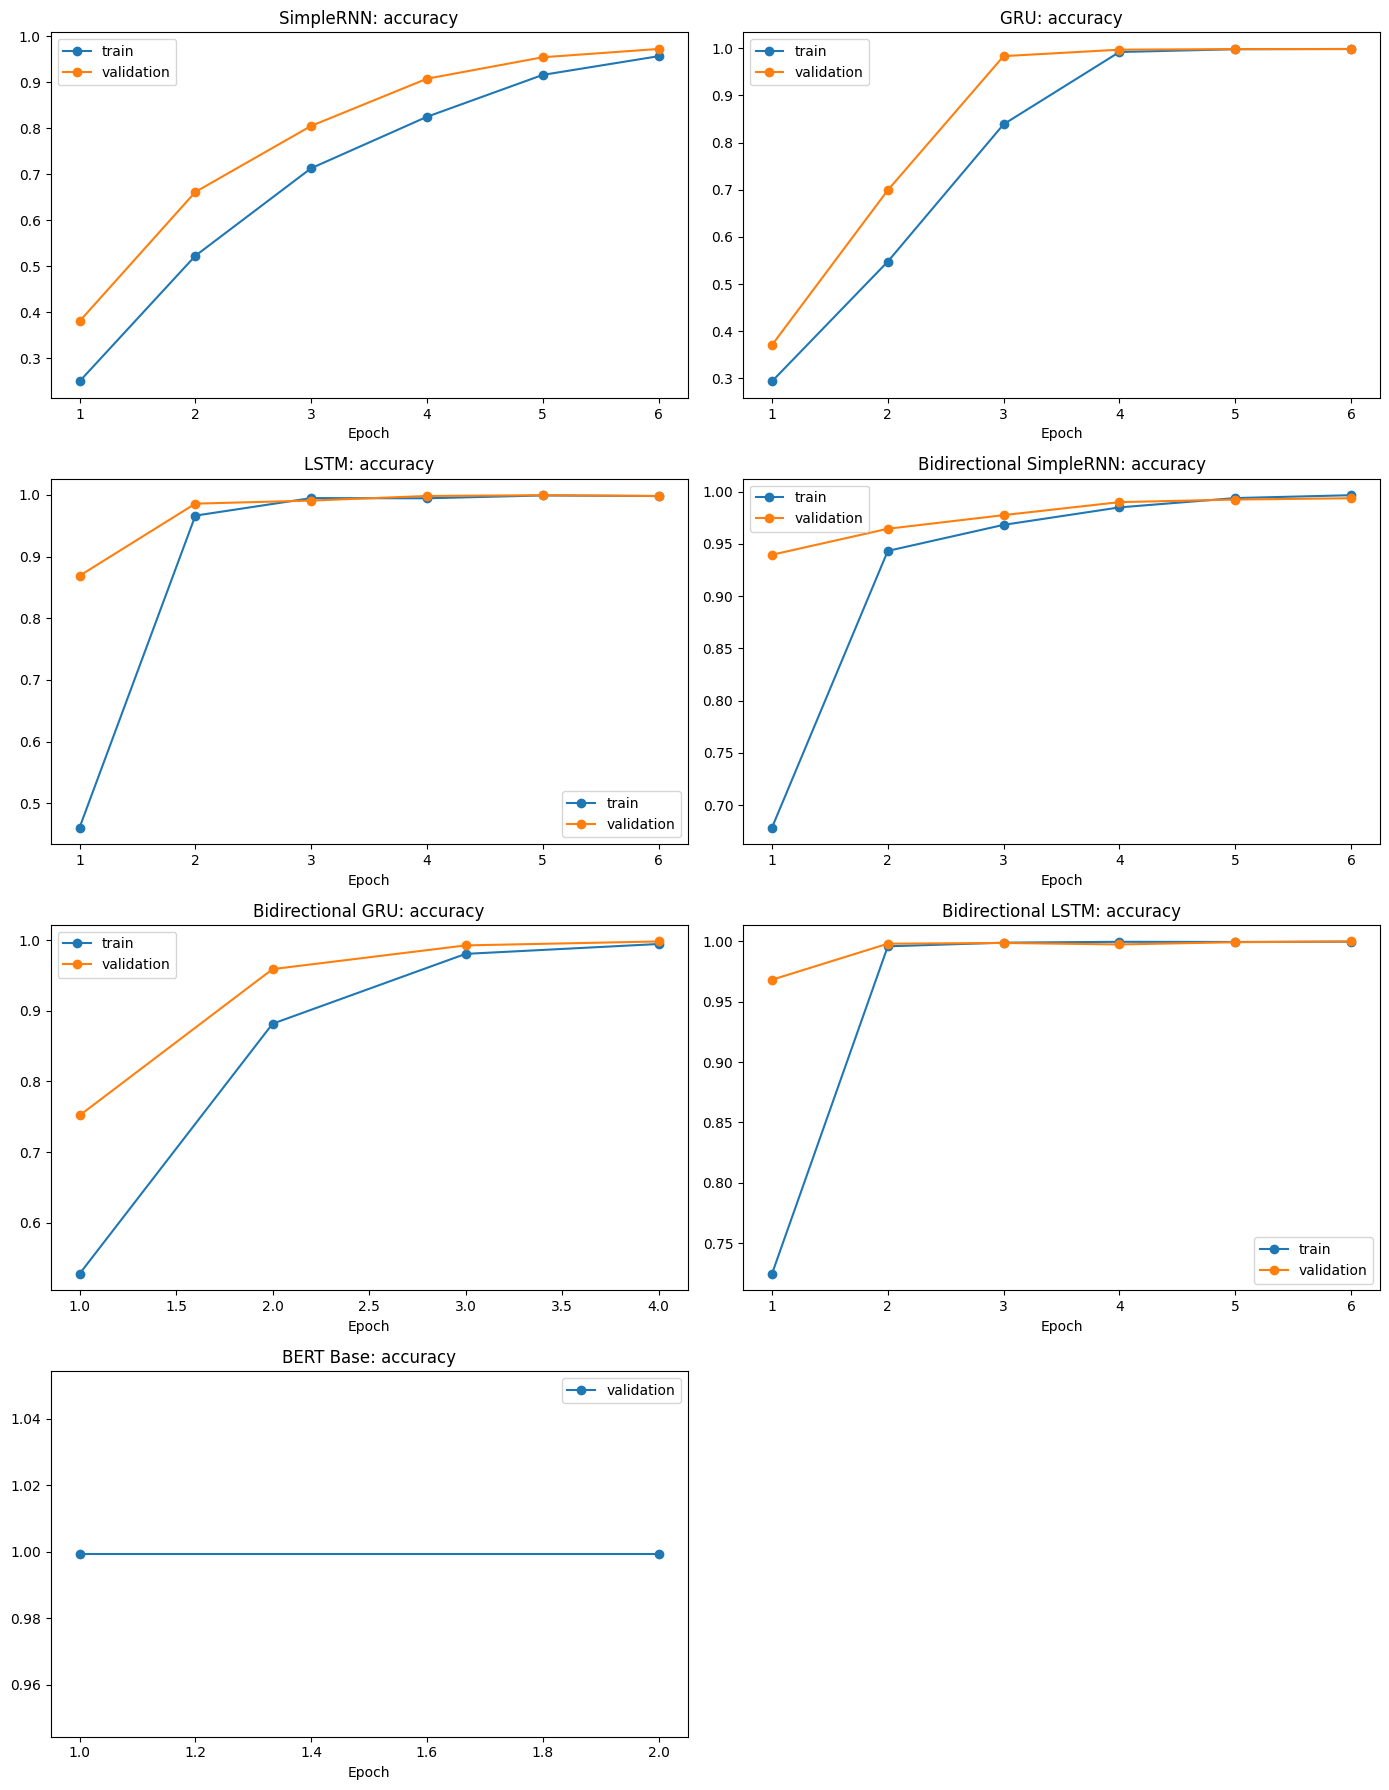

Selected neural accuracy curves generated from actual saved histories.


In [24]:
neural_names_with_bert = RECURRENT_MODELS + ["BERT Base"]
fig_loss, axes_loss = plt.subplots(4, 2, figsize=(14, 18))
fig_accuracy, axes_accuracy = plt.subplots(4, 2, figsize=(14, 18))
for loss_axis, accuracy_axis, model_name in zip(axes_loss.flat, axes_accuracy.flat, neural_names_with_bert):
    config_id = selected_configurations.get(model_name)
    history_file = OUTPUT_DIR / f"history_{config_id}.csv" if config_id else None
    if history_file and history_file.exists():
        history = pd.read_csv(history_file)
        if "loss" in history and "val_loss" in history:
            epochs = np.arange(1, len(history) + 1)
            loss_axis.plot(epochs, history["loss"], marker="o", label="train")
            loss_axis.plot(epochs, history["val_loss"], marker="o", label="validation")
            loss_axis.legend()
        if "accuracy" in history and "val_accuracy" in history:
            epochs = np.arange(1, len(history) + 1)
            accuracy_axis.plot(epochs, history["accuracy"], marker="o", label="train")
            accuracy_axis.plot(epochs, history["val_accuracy"], marker="o", label="validation")
            accuracy_axis.legend()
        elif "eval_accuracy" in history:
            filtered = history.dropna(subset=["eval_accuracy"])
            accuracy_axis.plot(filtered["epoch"], filtered["eval_accuracy"], marker="o", label="validation")
            accuracy_axis.legend()
    else:
        loss_axis.text(0.5, 0.5, "Not executed", ha="center", va="center")
        accuracy_axis.text(0.5, 0.5, "Not executed", ha="center", va="center")
    loss_axis.set_title(f"{model_name}: loss")
    loss_axis.set_xlabel("Epoch")
    accuracy_axis.set_title(f"{model_name}: accuracy")
    accuracy_axis.set_xlabel("Epoch")
for axis in axes_loss.flat[len(neural_names_with_bert):]:
    axis.axis("off")
for axis in axes_accuracy.flat[len(neural_names_with_bert):]:
    axis.axis("off")
fig_loss.tight_layout()
fig_accuracy.tight_layout()
plt.close(fig_loss)
fig_accuracy.savefig(OUTPUT_DIR / "selected_neural_accuracy_curves.png", dpi=180, bbox_inches="tight")
plt.show()
print("Selected neural accuracy curves generated from actual saved histories.")

## 14. Final Test Evaluation

Only the validation-selected configuration for each model is now evaluated on the frozen test set. The helper records accuracy, macro-F1, weighted-F1, full per-class precision/recall/F1/support, raw and normalized confusion matrices, training time, inference time, model size, probabilities, and per-example predictions.

In [25]:
MODEL_ORDER = ["Random Forest", "Logistic Regression", "Naive Bayes", "SimpleRNN", "GRU", "LSTM", "Bidirectional SimpleRNN", "Bidirectional GRU", "Bidirectional LSTM", "BERT Base"]
final_rows = []
per_class_rows = []
confusion_matrices = {}
normalized_confusion_matrices = {}
all_test_probabilities = {}
all_test_predictions = {}

def file_slug(text):
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")

def register_test_result(model_name, configuration_id, probabilities, inference_seconds, model_size_bytes):
    predicted_indices = probabilities.argmax(axis=1)
    predictions = np.array(CLASS_NAMES)[predicted_indices]
    truth = test_df[target_column].to_numpy()
    report_dictionary = classification_report(truth, predictions, labels=CLASS_NAMES, output_dict=True, zero_division=0)
    report_text = classification_report(truth, predictions, labels=CLASS_NAMES, zero_division=0)
    raw_matrix = confusion_matrix(truth, predictions, labels=CLASS_NAMES)
    normalized_matrix = confusion_matrix(truth, predictions, labels=CLASS_NAMES, normalize="true")
    training_row = tuning_table.loc[tuning_table["configuration_id"].eq(configuration_id)].iloc[0]
    final_rows.append({
        "model_name": model_name,
        "selected_configuration": configuration_id,
        "accuracy": accuracy_score(truth, predictions),
        "macro_f1": f1_score(truth, predictions, average="macro"),
        "weighted_f1": f1_score(truth, predictions, average="weighted"),
        "training_time_seconds": training_row["training_time_seconds"],
        "inference_time_seconds": inference_seconds,
        "model_size_mb": model_size_bytes / 2**20,
        "evaluation_status": "completed",
        "failure_reason": ""
    })
    for label in CLASS_NAMES:
        metrics = report_dictionary[label]
        per_class_rows.append({"model_name": model_name, "class_label": label, "precision": metrics["precision"], "recall": metrics["recall"], "f1_score": metrics["f1-score"], "support": metrics["support"]})
    slug = file_slug(model_name)
    pd.DataFrame(raw_matrix, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / f"confusion_matrix_{slug}.csv")
    pd.DataFrame(normalized_matrix, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / f"normalized_confusion_matrix_{slug}.csv")
    with open(OUTPUT_DIR / f"classification_report_{slug}.txt", "w", encoding="utf-8") as handle:
        handle.write(report_text)
    prediction_frame = test_df[["conversation_id", target_column, "context_type", "word_count", "text_minimal"]].reset_index(drop=True).copy()
    prediction_frame["predicted_label"] = predictions
    prediction_frame["confidence"] = probabilities.max(axis=1)
    prediction_frame["correct"] = prediction_frame[target_column].eq(prediction_frame["predicted_label"])
    prediction_frame.to_csv(OUTPUT_DIR / f"test_predictions_{slug}.csv", index=False)
    probability_path = OUTPUT_DIR / f"test_probabilities_{configuration_id}.npy"
    np.save(probability_path, probabilities)
    confusion_matrices[model_name] = raw_matrix
    normalized_confusion_matrices[model_name] = normalized_matrix
    all_test_probabilities[model_name] = probabilities
    all_test_predictions[model_name] = prediction_frame
    print(f"{model_name}: test accuracy={final_rows[-1]['accuracy']:.4f}, macro-F1={final_rows[-1]['macro_f1']:.4f}")

print("Final test evaluation helper initialized.")

Final test evaluation helper initialized.


In [26]:
for model_name in ["Random Forest", "Logistic Regression", "Naive Bayes"]:
    config_id = selected_configurations.get(model_name)
    if not config_id:
        continue
    config = next(item for item in classical_configs if item["config_id"] == config_id)
    text_column = feature_column(config["preprocessing"])
    model_path = CHECKPOINT_DIR / f"{config_id}.joblib"
    fitted_model = joblib.load(model_path)
    started = time.perf_counter()
    probabilities = ordered_probabilities(fitted_model, test_df[text_column])
    inference_seconds = time.perf_counter() - started
    register_test_result(model_name, config_id, probabilities, inference_seconds, model_path.stat().st_size)
    del fitted_model

for model_name in RECURRENT_MODELS:
    config_id = selected_configurations.get(model_name)
    if not config_id:
        continue
    model_path = CHECKPOINT_DIR / f"{config_id}.keras"
    recurrent_model = tf.keras.models.load_model(model_path)
    config = next(item for item in neural_configs if item["config_id"] == config_id)
    started = time.perf_counter()
    probabilities = recurrent_model.predict(X_test_sequence, batch_size=config["batch_size"], verbose=0)
    inference_seconds = time.perf_counter() - started
    register_test_result(model_name, config_id, probabilities, inference_seconds, model_path.stat().st_size)
    del recurrent_model
    tf.keras.backend.clear_session()
    gc.collect()

print(f"Individual models evaluated on test so far: {len(final_rows)}")

Random Forest: test accuracy=1.0000, macro-F1=1.0000
Logistic Regression: test accuracy=1.0000, macro-F1=1.0000
Naive Bayes: test accuracy=1.0000, macro-F1=1.0000


2026-08-24 18:38:42.220647: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


SimpleRNN: test accuracy=0.9732, macro-F1=0.9692
GRU: test accuracy=0.9979, macro-F1=0.9977
LSTM: test accuracy=0.9993, macro-F1=0.9992


2026-08-24 18:38:48.799935: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Bidirectional SimpleRNN: test accuracy=0.9966, macro-F1=0.9960
Bidirectional GRU: test accuracy=0.9972, macro-F1=0.9968


2026-08-24 18:38:54.009657: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Bidirectional LSTM: test accuracy=0.9993, macro-F1=0.9992
Individual models evaluated on test so far: 9


In [27]:
if "BERT Base" in selected_configurations and RUN_BERT:
    from torch.utils.data import DataLoader
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    config_id = selected_configurations["BERT Base"]
    config = next(item for item in bert_configs if item["config_id"] == config_id)
    selected_path = CHECKPOINT_DIR / config_id / "selected_checkpoint"
    if not selected_path.exists():
        raise FileNotFoundError(f"Selected BERT checkpoint is missing: {selected_path}")

    tokenizer = AutoTokenizer.from_pretrained(str(selected_path), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(selected_path))
    device = torch.device("cuda")
    model.to(device)
    model.eval()

    test_dataset_bert = EncodedConversationDataset(
        test_df["text_minimal"], y_test_encoded, tokenizer, config["max_length"]
    )
    test_loader_bert = DataLoader(
        test_dataset_bert,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    probability_batches = []
    started = time.perf_counter()
    with torch.no_grad():
        for batch in test_loader_bert:
            batch.pop("labels", None)
            batch = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(**batch).logits
            probability_batches.append(torch.softmax(logits, dim=1).cpu().numpy())

    probabilities = np.concatenate(probability_batches, axis=0)
    inference_seconds = time.perf_counter() - started
    model_size_bytes = sum(path.stat().st_size for path in selected_path.rglob("*") if path.is_file())
    register_test_result("BERT Base", config_id, probabilities, inference_seconds, model_size_bytes)

    del model, tokenizer, test_dataset_bert, test_loader_bert, probability_batches
    gc.collect()
    torch.cuda.empty_cache()
else:
    bert_failures = tuning_table.loc[
        tuning_table["model_name"].eq("BERT Base"), "failure_reason"
    ].dropna()
    reason = bert_failures.iloc[0] if not bert_failures.empty else "No completed BERT configuration was available."
    final_rows.append({
        "model_name": "BERT Base",
        "selected_configuration": "not_available",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "weighted_f1": np.nan,
        "training_time_seconds": 0.0,
        "inference_time_seconds": 0.0,
        "model_size_mb": np.nan,
        "evaluation_status": "not_executed",
        "failure_reason": reason,
    })
    print(f"BERT Base test evaluation not executed: {reason}")

final_results = pd.DataFrame(final_rows)
final_results["order"] = final_results["model_name"].map({name: index for index, name in enumerate(MODEL_ORDER)})
final_results = final_results.sort_values("order").drop(columns="order").reset_index(drop=True)
per_class_results = pd.DataFrame(per_class_rows)
final_results.to_csv(OUTPUT_DIR / "final_model_comparison.csv", index=False)
per_class_results.to_csv(OUTPUT_DIR / "per_class_metrics.csv", index=False)
display(final_results.round(4))
print(f"Completed final test evaluations: {(final_results['evaluation_status'] == 'completed').sum()} / 10")

BERT Base: test accuracy=1.0000, macro-F1=1.0000


,model_name,selected_configuration,accuracy,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds,model_size_mb,evaluation_status,failure_reason
0,Random Forest,RF_C3,1.0000,1.0000,1.0000,10.2700,0.5547,30.5229,completed,
1,Logistic Regression,LR_C1,1.0000,1.0000,1.0000,1.4822,0.1139,0.2502,completed,
2,Naive Bayes,NB_C2,1.0000,1.0000,1.0000,0.3801,0.0847,0.4031,completed,
3,SimpleRNN,SRNN_C3,0.9732,0.9692,0.9729,74.7046,0.9380,1.0122,completed,
4,GRU,GRU_C3,0.9979,0.9977,0.9979,7.8851,0.3630,1.1776,completed,
5,LSTM,LSTM_C3,0.9993,0.9992,0.9993,8.0176,0.4190,1.2578,completed,
6,Bidirectional SimpleRNN,BSRNN_C3,0.9966,0.9960,0.9966,108.8325,1.3698,1.1083,completed,
7,Bidirectional GRU,BGRU_C1,0.9972,0.9968,0.9973,5.3663,0.4949,0.6388,completed,
8,Bidirectional LSTM,BLSTM_C3,0.9993,0.9992,0.9993,11.0800,0.5925,1.5995,completed,
9,BERT Base,BERT_C1,1.0000,1.0000,1.0000,216.5061,2.3020,418.5920,completed,


Completed final test evaluations: 10 / 10


## 15. Model Comparison

The consolidated figures compare accuracy, macro-F1, training cost, per-class F1, and confusion structure. Missing panels are explicitly labeled instead of filled with invented results.

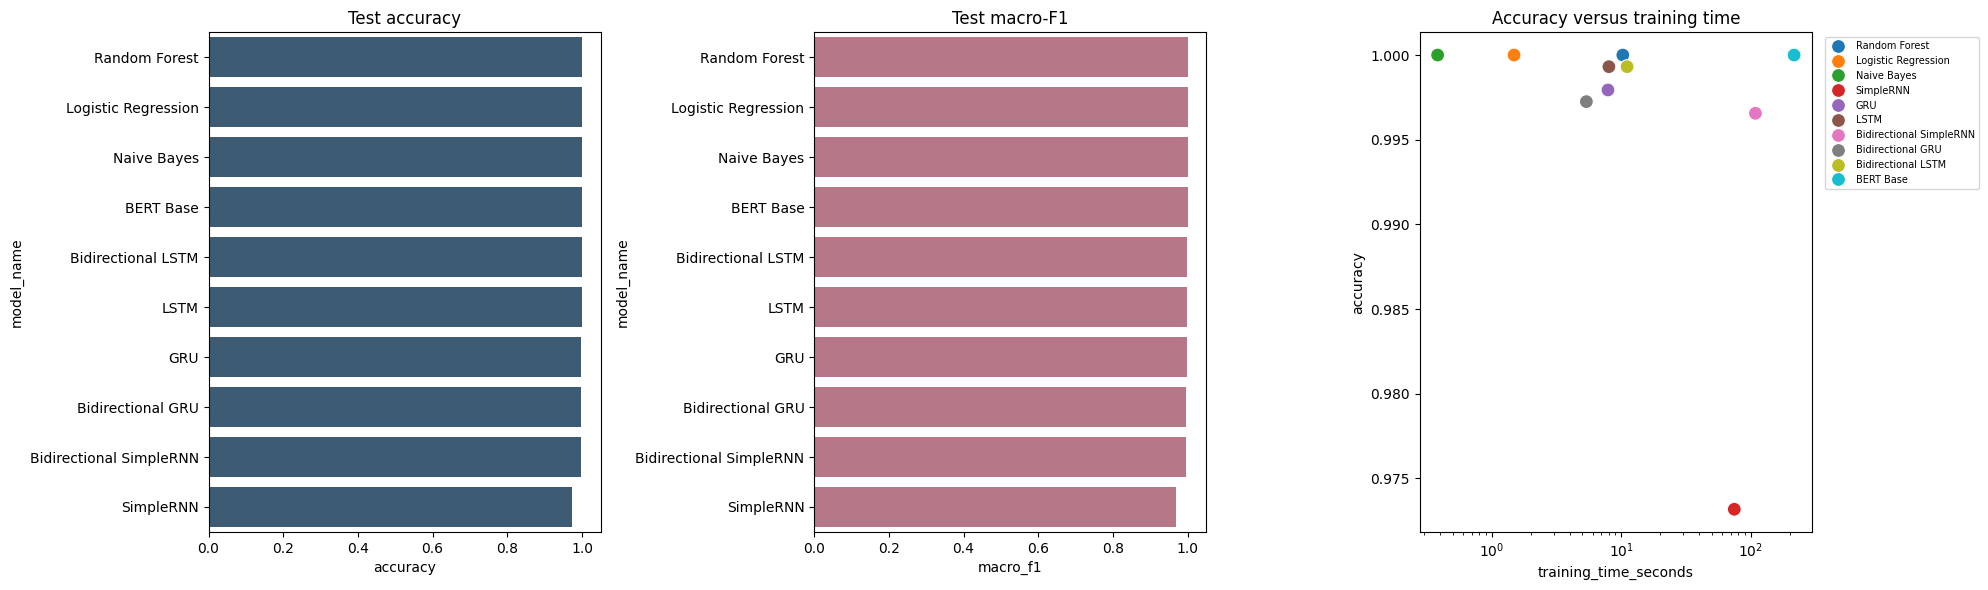

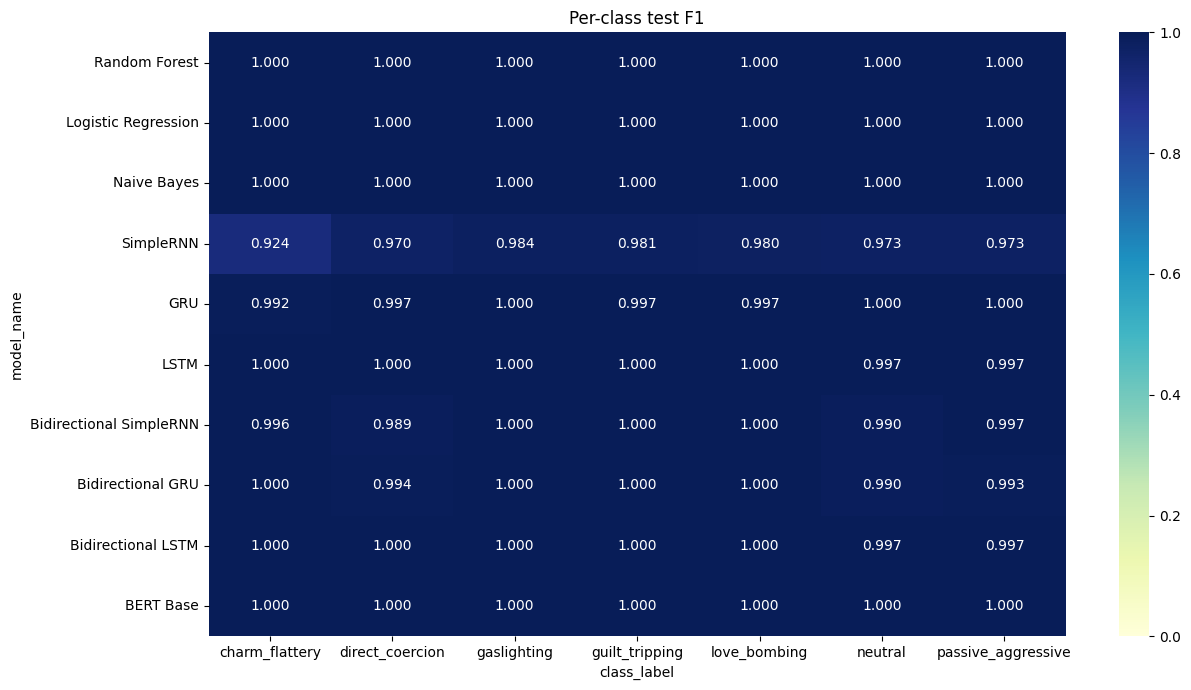

class_label,charm_flattery,direct_coercion,gaslighting,guilt_tripping,love_bombing,neutral,passive_aggressive
model_name,,,,,,,
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
SimpleRNN,0.9237,0.9700,0.9838,0.9810,0.9802,0.9730,0.9728
GRU,0.9924,0.9972,1.0000,0.9973,0.9966,1.0000,1.0000
LSTM,1.0000,1.0000,1.0000,1.0000,1.0000,0.9975,0.9967
Bidirectional SimpleRNN,0.9962,0.9890,1.0000,1.0000,1.0000,0.9899,0.9967
Bidirectional GRU,1.0000,0.9945,1.0000,1.0000,1.0000,0.9900,0.9933
Bidirectional LSTM,1.0000,1.0000,1.0000,1.0000,1.0000,0.9975,0.9967


Model comparison figures saved from actual completed test evaluations.


In [28]:
completed_final = final_results.loc[final_results["evaluation_status"].eq("completed")].copy()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(data=completed_final.sort_values("accuracy", ascending=False), x="accuracy", y="model_name", ax=axes[0], color="#355C7D")
axes[0].set_title("Test accuracy")
sns.barplot(data=completed_final.sort_values("macro_f1", ascending=False), x="macro_f1", y="model_name", ax=axes[1], color="#C06C84")
axes[1].set_title("Test macro-F1")
sns.scatterplot(data=completed_final, x="training_time_seconds", y="accuracy", hue="model_name", s=100, ax=axes[2])
axes[2].set_xscale("log")
axes[2].set_title("Accuracy versus training time")
axes[2].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_charts.png", dpi=180, bbox_inches="tight")
plt.show()

if not per_class_results.empty:
    per_class_pivot = per_class_results.pivot(index="model_name", columns="class_label", values="f1_score").reindex([name for name in MODEL_ORDER if name in per_class_results["model_name"].unique()])
    plt.figure(figsize=(13, 7))
    sns.heatmap(per_class_pivot, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("Per-class test F1")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "per_class_f1_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()
    display(per_class_pivot.round(4))
print("Model comparison figures saved from actual completed test evaluations.")

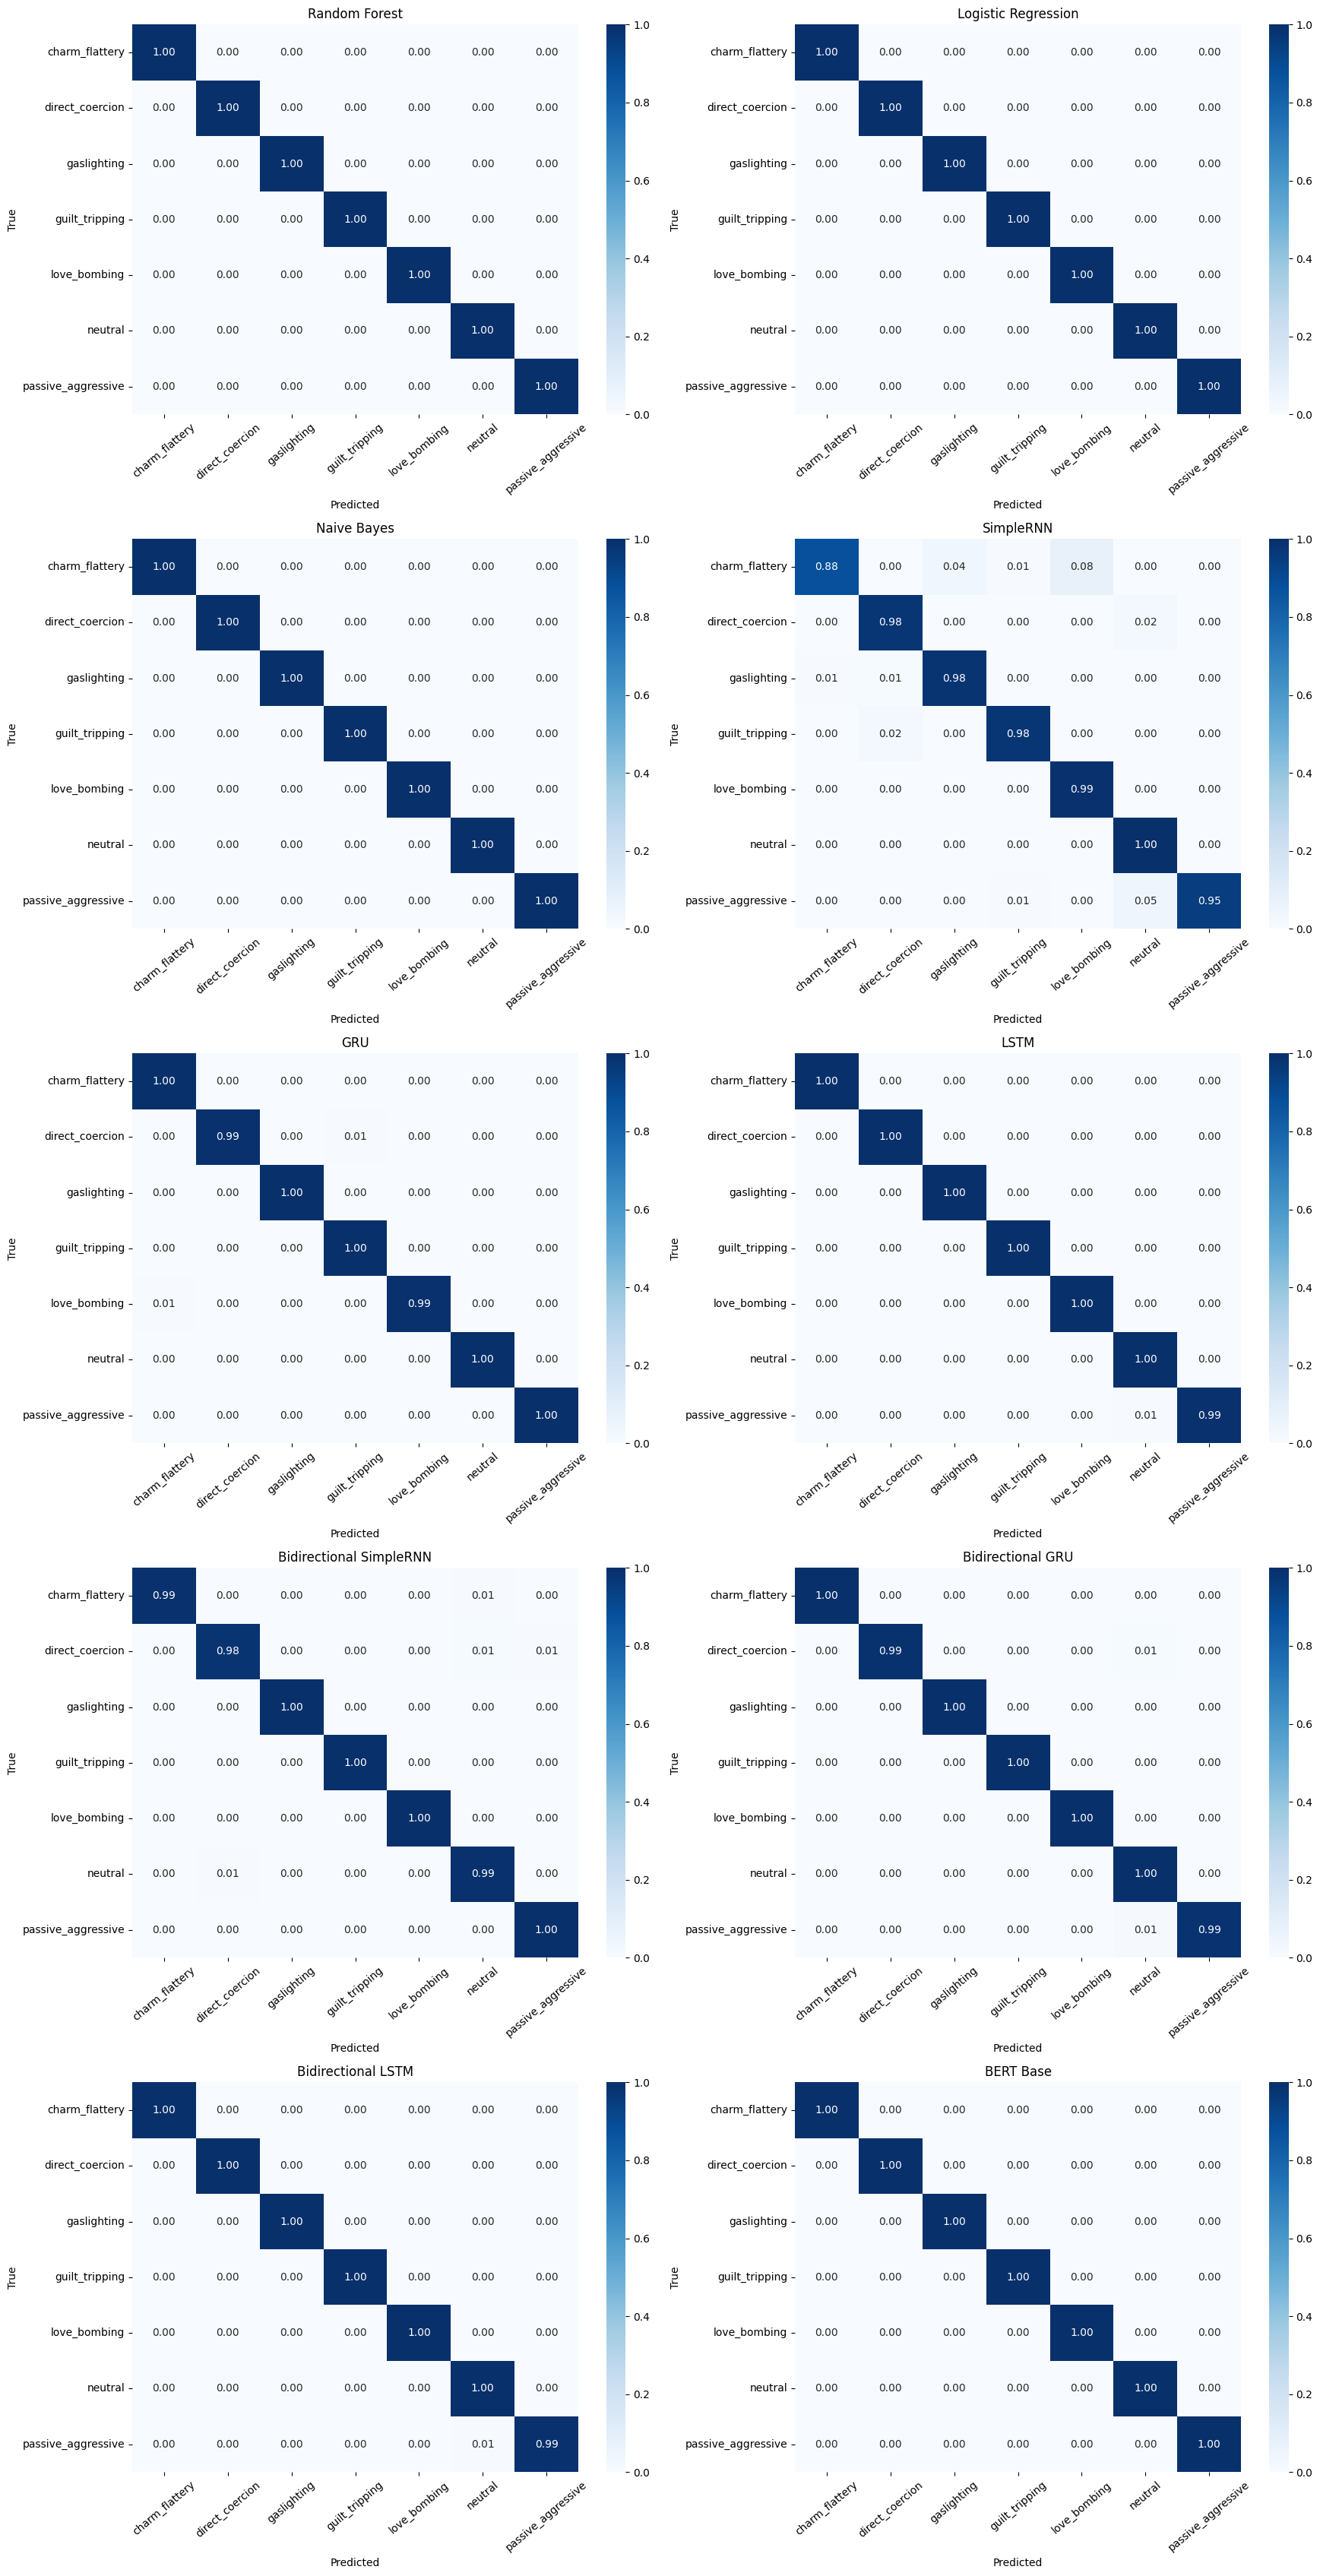

Tie-selected representative for error analysis: Random Forest | accuracy=1.0000 | macro-F1=1.0000
Worst completed individual model: SimpleRNN | accuracy=0.9732 | macro-F1=0.9692


In [29]:
fig, axes = plt.subplots(5, 2, figsize=(18, 34))
for axis, model_name in zip(axes.flat, MODEL_ORDER):
    if model_name in normalized_confusion_matrices:
        sns.heatmap(normalized_confusion_matrices[model_name], annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axis)
        axis.set_xlabel("Predicted")
        axis.set_ylabel("True")
        axis.tick_params(axis="x", rotation=40)
        axis.tick_params(axis="y", rotation=0)
    else:
        axis.text(0.5, 0.5, "Not executed", ha="center", va="center", fontsize=13)
        axis.set_xticks([])
        axis.set_yticks([])
    axis.set_title(model_name)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_normalized_confusion_matrices.png", dpi=170, bbox_inches="tight")
plt.show()

best_individual_row = completed_final.sort_values(["macro_f1", "accuracy"], ascending=False).iloc[0]
worst_individual_row = completed_final.sort_values(["macro_f1", "accuracy"], ascending=True).iloc[0]
print(f"Tie-selected representative for error analysis: {best_individual_row['model_name']} | accuracy={best_individual_row['accuracy']:.4f} | macro-F1={best_individual_row['macro_f1']:.4f}")
print(f"Worst completed individual model: {worst_individual_row['model_name']} | accuracy={worst_individual_row['accuracy']:.4f} | macro-F1={worst_individual_row['macro_f1']:.4f}")

## 16. Bonus Ensemble

Complementary validation-selected models are combined by probability, never by test-set tuning. Equal soft voting is compared with a small validation-only integer-weight grid. The winning weighting is frozen, then evaluated once on the test set. Probability columns already follow the same sorted class order.

In [30]:
from itertools import product

validation_completed = tuning_table.loc[tuning_table["selection_decision"].eq("selected_by_validation_macro_f1")].copy()
classical_candidates = validation_completed.loc[validation_completed["model_name"].isin(["Random Forest", "Logistic Regression", "Naive Bayes"])]
recurrent_candidates = validation_completed.loc[validation_completed["model_name"].isin(RECURRENT_MODELS)]
ensemble_components = []
if not classical_candidates.empty:
    ensemble_components.append(classical_candidates.sort_values(["validation_macro_f1", "validation_accuracy"], ascending=False).iloc[0])
if not recurrent_candidates.empty:
    ensemble_components.append(recurrent_candidates.sort_values(["validation_macro_f1", "validation_accuracy"], ascending=False).iloc[0])
bert_candidate = validation_completed.loc[validation_completed["model_name"].eq("BERT Base")]
if not bert_candidate.empty:
    ensemble_components.append(bert_candidate.iloc[0])

component_names = [row["model_name"] for row in ensemble_components]
component_ids = [row["configuration_id"] for row in ensemble_components]
validation_component_probabilities = [np.load(OUTPUT_DIR / f"validation_probabilities_{config_id}.npy") for config_id in component_ids]
equal_weights = np.ones(len(component_ids)) / max(len(component_ids), 1)

ensemble_validation_rows = []
if len(component_ids) >= 2:
    candidate_weights = [equal_weights]
    for weights in product([1.0, 2.0, 3.0], repeat=len(component_ids)):
        normalized_weights = np.asarray(weights) / np.sum(weights)
        candidate_weights.append(normalized_weights)
    seen_weights = set()
    unique_weights = []
    for weights in candidate_weights:
        key = tuple(np.round(weights, 6))
        if key not in seen_weights:
            seen_weights.add(key)
            unique_weights.append(weights)
    for weights in unique_weights:
        probability_sum = sum(weight * probabilities for weight, probabilities in zip(weights, validation_component_probabilities))
        predictions = np.array(CLASS_NAMES)[probability_sum.argmax(axis=1)]
        ensemble_validation_rows.append({
            "weights": json.dumps({name: float(weight) for name, weight in zip(component_names, weights)}, sort_keys=True),
            "validation_accuracy": accuracy_score(val_df[target_column], predictions),
            "validation_macro_f1": f1_score(val_df[target_column], predictions, average="macro"),
            "validation_weighted_f1": f1_score(val_df[target_column], predictions, average="weighted")
        })
    ensemble_validation_table = pd.DataFrame(ensemble_validation_rows).sort_values(["validation_macro_f1", "validation_accuracy"], ascending=False).reset_index(drop=True)
    chosen_weights_dictionary = json.loads(ensemble_validation_table.iloc[0]["weights"])
    chosen_weights = np.array([chosen_weights_dictionary[name] for name in component_names])
    test_component_probabilities = [all_test_probabilities[name] for name in component_names]
    ensemble_test_probabilities = sum(weight * probabilities for weight, probabilities in zip(chosen_weights, test_component_probabilities))
    ensemble_test_predictions = np.array(CLASS_NAMES)[ensemble_test_probabilities.argmax(axis=1)]
    ensemble_accuracy = accuracy_score(test_df[target_column], ensemble_test_predictions)
    ensemble_macro_f1 = f1_score(test_df[target_column], ensemble_test_predictions, average="macro")
    ensemble_weighted_f1 = f1_score(test_df[target_column], ensemble_test_predictions, average="weighted")
    ensemble_improved = ensemble_macro_f1 > best_individual_row["macro_f1"]
    ensemble_result = pd.DataFrame([{
        "components": json.dumps(component_names),
        "selected_weights": json.dumps(chosen_weights_dictionary, sort_keys=True),
        "validation_macro_f1": ensemble_validation_table.iloc[0]["validation_macro_f1"],
        "test_accuracy": ensemble_accuracy,
        "test_macro_f1": ensemble_macro_f1,
        "test_weighted_f1": ensemble_weighted_f1,
        "best_individual_macro_f1": best_individual_row["macro_f1"],
        "genuine_macro_f1_improvement": bool(ensemble_improved)
    }])
    ensemble_validation_table.to_csv(OUTPUT_DIR / "ensemble_validation_weight_search.csv", index=False)
    ensemble_result.to_csv(OUTPUT_DIR / "ensemble_result.csv", index=False)
    np.save(OUTPUT_DIR / "ensemble_test_probabilities.npy", ensemble_test_probabilities)
    display(ensemble_validation_table.head(10).round(4))
    display(ensemble_result.round(4))
    print(f"Chosen ensemble components: {component_names}")
    print(f"Genuine test macro-F1 improvement: {ensemble_improved}")
else:
    ensemble_validation_table = pd.DataFrame()
    ensemble_result = pd.DataFrame([{"components": json.dumps(component_names), "selected_weights": "", "validation_macro_f1": np.nan, "test_accuracy": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan, "best_individual_macro_f1": best_individual_row["macro_f1"], "genuine_macro_f1_improvement": False}])
    ensemble_result.to_csv(OUTPUT_DIR / "ensemble_result.csv", index=False)
    print("Ensemble not executed because fewer than two complementary completed models were available.")

,weights,validation_accuracy,validation_macro_f1,validation_weighted_f1
0,"{""BERT Base"": 0.2, ""Bidirectional LSTM"": 0.6, ...",1.0000,1.0000,1.0000
1,"{""BERT Base"": 0.2, ""Bidirectional LSTM"": 0.4, ...",1.0000,1.0000,1.0000
2,"{""BERT Base"": 0.16666666666666666, ""Bidirectio...",1.0000,1.0000,1.0000
3,"{""BERT Base"": 0.16666666666666666, ""Bidirectio...",1.0000,1.0000,1.0000
4,"{""BERT Base"": 0.14285714285714285, ""Bidirectio...",1.0000,1.0000,1.0000
5,"{""BERT Base"": 0.3333333333333333, ""Bidirection...",0.9994,0.9995,0.9994
6,"{""BERT Base"": 0.5, ""Bidirectional LSTM"": 0.25,...",0.9994,0.9995,0.9994
7,"{""BERT Base"": 0.6, ""Bidirectional LSTM"": 0.2, ...",0.9994,0.9995,0.9994
8,"{""BERT Base"": 0.25, ""Bidirectional LSTM"": 0.5,...",0.9994,0.9995,0.9994
9,"{""BERT Base"": 0.4, ""Bidirectional LSTM"": 0.4, ...",0.9994,0.9995,0.9994


,components,selected_weights,validation_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,best_individual_macro_f1,genuine_macro_f1_improvement
0,"[""Random Forest"", ""Bidirectional LSTM"", ""BERT ...","{""BERT Base"": 0.2, ""Bidirectional LSTM"": 0.6, ...",1.0,1.0,1.0,1.0,1.0,False


Chosen ensemble components: ['Random Forest', 'Bidirectional LSTM', 'BERT Base']
Genuine test macro-F1 improvement: False


## 17. Bonus Ablation Studies

Controlled validation-only ablations change one component at a time: speaker markers, preprocessing strategy, embedding source, bidirectionality, and split policy. The ordinary stratified split comparison is diagnostic only; the final pipeline remains group-aware because leakage prevention has priority.

,ablation_family,variant,validation_accuracy,validation_macro_f1
0,speaker_markers,with_markers,1.0000,1.0000
1,speaker_markers,without_markers,1.0000,1.0000
2,preprocessing,minimal,1.0000,1.0000
3,preprocessing,normalized,1.0000,1.0000
4,embedding_source,Word2Vec,0.9994,0.9992
5,embedding_source,GloVe,0.9639,0.9625
6,directionality_SimpleRNN,unidirectional,0.6063,0.5669
7,directionality_SimpleRNN,bidirectional,0.9701,0.9714
8,directionality_GRU,unidirectional,0.9627,0.9604
9,directionality_GRU,bidirectional,0.9981,0.9983


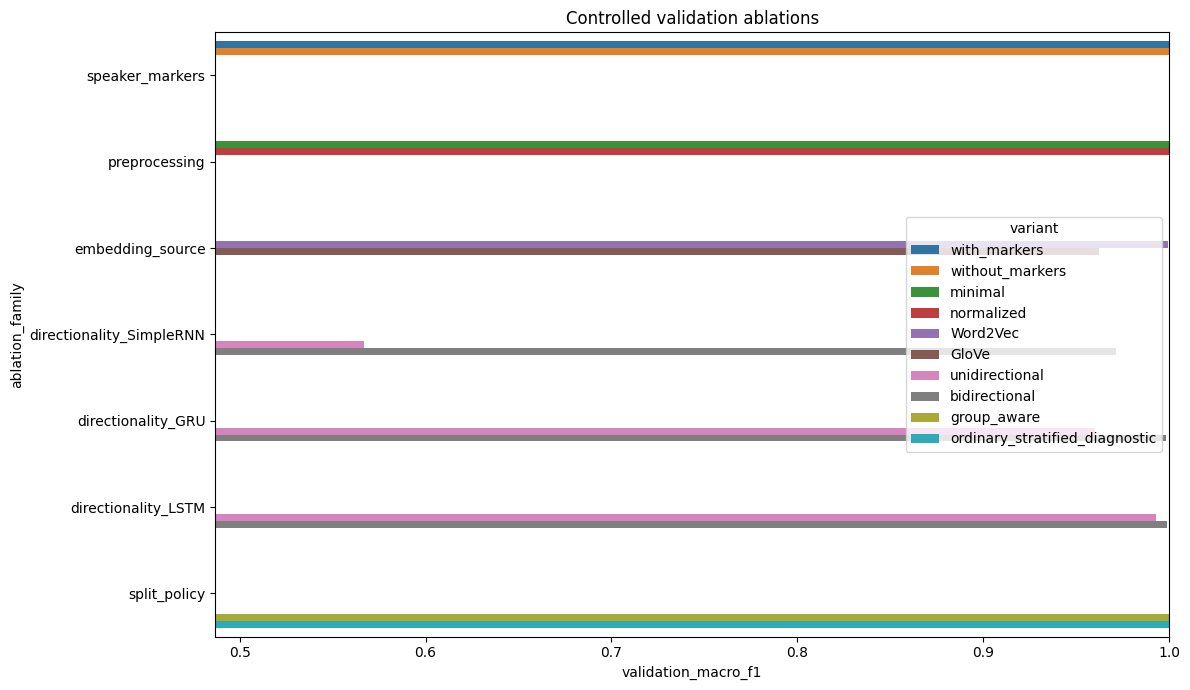

Ablations use validation performance only; no test metric influenced a preprocessing, architecture, or ensemble choice.


In [31]:
from sklearn.model_selection import train_test_split

ablation_rows = []

def run_text_ablation(name, training_text, validation_text):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=False, ngram_range=(1, 2), min_df=2, max_features=40000, sublinear_tf=True, dtype=np.float32)),
        ("model", LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE))
    ])
    pipeline.fit(training_text, train_df[target_column])
    predictions = pipeline.predict(validation_text)
    return {"ablation_family": name.split(":")[0], "variant": name.split(":", 1)[1], "validation_accuracy": accuracy_score(val_df[target_column], predictions), "validation_macro_f1": f1_score(val_df[target_column], predictions, average="macro")}

ablation_rows.append(run_text_ablation("speaker_markers:with_markers", train_df["text_minimal"], val_df["text_minimal"]))
ablation_rows.append(run_text_ablation("speaker_markers:without_markers", train_df["text_no_speakers"], val_df["text_no_speakers"]))
ablation_rows.append(run_text_ablation("preprocessing:minimal", train_df["text_minimal"], val_df["text_minimal"]))
ablation_rows.append(run_text_ablation("preprocessing:normalized", train_df["text_normalized"], val_df["text_normalized"]))

def average_embeddings(token_sequences, keyed_vectors):
    vectors = []
    for sequence in token_sequences:
        available = [keyed_vectors[token] for token in sequence if token in keyed_vectors]
        vectors.append(np.mean(available, axis=0) if available else np.zeros(keyed_vectors.vector_size))
    return np.asarray(vectors, dtype=np.float32)

for embedding_name, keyed_vectors in [("Word2Vec", word2vec_model.wv), ("GloVe", glove_model)]:
    train_average = average_embeddings(train_tokens, keyed_vectors)
    validation_average = average_embeddings(val_tokens, keyed_vectors)
    embedding_classifier = LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE)
    embedding_classifier.fit(train_average, train_df[target_column])
    predictions = embedding_classifier.predict(validation_average)
    ablation_rows.append({"ablation_family": "embedding_source", "variant": embedding_name, "validation_accuracy": accuracy_score(val_df[target_column], predictions), "validation_macro_f1": f1_score(val_df[target_column], predictions, average="macro")})

for base_name, bidirectional_name in [("SimpleRNN", "Bidirectional SimpleRNN"), ("GRU", "Bidirectional GRU"), ("LSTM", "Bidirectional LSTM")]:
    for model_name in [base_name, bidirectional_name]:
        row = tuning_table.loc[(tuning_table["model_name"].eq(model_name)) & (tuning_table["configuration_id"].str.endswith("C1"))].iloc[0]
        ablation_rows.append({"ablation_family": f"directionality_{base_name}", "variant": "bidirectional" if model_name.startswith("Bidirectional") else "unidirectional", "validation_accuracy": row["validation_accuracy"], "validation_macro_f1": row["validation_macro_f1"]})

standard_train_indices, standard_hold_indices = train_test_split(np.arange(len(df)), test_size=0.30, random_state=RANDOM_STATE, stratify=df[target_column])
standard_val_indices, standard_test_indices = train_test_split(standard_hold_indices, test_size=0.50, random_state=RANDOM_STATE, stratify=df.iloc[standard_hold_indices][target_column])
standard_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=40000, sublinear_tf=True, dtype=np.float32)),
    ("model", LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE))
])
standard_pipeline.fit(df.iloc[standard_train_indices]["text_minimal"], df.iloc[standard_train_indices][target_column])
standard_predictions = standard_pipeline.predict(df.iloc[standard_val_indices]["text_minimal"])
group_row = next(item for item in ablation_rows if item["ablation_family"] == "speaker_markers" and item["variant"] == "with_markers")
ablation_rows.append({"ablation_family": "split_policy", "variant": "group_aware", "validation_accuracy": group_row["validation_accuracy"], "validation_macro_f1": group_row["validation_macro_f1"]})
ablation_rows.append({"ablation_family": "split_policy", "variant": "ordinary_stratified_diagnostic", "validation_accuracy": accuracy_score(df.iloc[standard_val_indices][target_column], standard_predictions), "validation_macro_f1": f1_score(df.iloc[standard_val_indices][target_column], standard_predictions, average="macro")})

ablation_results = pd.DataFrame(ablation_rows)
ablation_results.to_csv(OUTPUT_DIR / "ablation_results.csv", index=False)
display(ablation_results.round(4))

plt.figure(figsize=(12, 7))
sns.barplot(data=ablation_results, x="validation_macro_f1", y="ablation_family", hue="variant")
plt.title("Controlled validation ablations")
plt.xlim(max(0, ablation_results["validation_macro_f1"].min() - 0.08), 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_results.png", dpi=180, bbox_inches="tight")
plt.show()
print("Ablations use validation performance only; no test metric influenced a preprocessing, architecture, or ensemble choice.")

## 18. Error Analysis

Error analysis compares a tie-selected leading representative with the weakest completed model. It covers confusion pairs, neutral-related errors, length and context subgroups, confidence, high-confidence mistakes, and at least 15 representative misclassifications. Labels are never edited after inspection.

In [32]:
error_models = [best_individual_row["model_name"], worst_individual_row["model_name"]]
error_analysis_tables = []

for model_name in error_models:
    predictions = all_test_predictions[model_name].copy()
    incorrect = predictions.loc[~predictions["correct"]].copy()
    confusion_pairs = incorrect.groupby([target_column, "predicted_label"]).size().rename("count").reset_index().sort_values("count", ascending=False).head(10)
    predictions["length_bucket"] = pd.cut(predictions["word_count"], bins=[-np.inf, 30, 50, np.inf], labels=["short", "medium", "long"])
    length_performance = predictions.groupby("length_bucket", observed=False)["correct"].agg(["mean", "count"]).reset_index()
    context_performance = predictions.groupby("context_type")["correct"].agg(["mean", "count"]).reset_index()
    neutral_errors = pd.DataFrame({
        "error_type": ["manipulation predicted neutral", "neutral predicted manipulation"],
        "count": [((predictions[target_column] != "neutral") & (predictions["predicted_label"] == "neutral")).sum(), ((predictions[target_column] == "neutral") & (predictions["predicted_label"] != "neutral")).sum()]
    })
    representative_errors = incorrect.sort_values("confidence", ascending=False).head(15).copy()
    representative_errors["text_minimal"] = representative_errors["text_minimal"].str.slice(0, 420)
    representative_errors["model_name"] = model_name
    representative_errors.to_csv(OUTPUT_DIR / f"representative_errors_{file_slug(model_name)}.csv", index=False)
    error_analysis_tables.append(representative_errors)

    print(f"\n{model_name}: {len(incorrect)} incorrect of {len(predictions)}")
    print(f"Mean confidence on incorrect predictions: {incorrect['confidence'].mean():.4f}")
    display(confusion_pairs)
    display(neutral_errors)
    display(length_performance.round(4))
    display(context_performance.round(4))
    display(representative_errors[[target_column, "predicted_label", "confidence", "context_type", "word_count", "text_minimal"]])

combined_error_examples = pd.concat(error_analysis_tables, ignore_index=True)
combined_error_examples.to_csv(OUTPUT_DIR / "error_analysis_examples.csv", index=False)
print("Potential causes include annotation ambiguity between adjacent manipulation strategies, short-context uncertainty, lexical shortcuts, and recurring synthetic templates. These hypotheses are interpretive and do not change the labels.")


Random Forest: 0 incorrect of 1454
Mean confidence on incorrect predictions: nan


,manipulation_type,predicted_label,count


,error_type,count
0,manipulation predicted neutral,0
1,neutral predicted manipulation,0


,length_bucket,mean,count
0,short,1.0,119
1,medium,1.0,581
2,long,1.0,754


,context_type,mean,count
0,coworker,1.0,355
1,family,1.0,362
2,friend,1.0,394
3,romantic,1.0,343


...

,length_bucket,mean,count
0,short,0.9412,119
1,medium,0.9742,581
2,long,0.9775,754


,context_type,mean,count
0,coworker,0.9775,355
1,family,0.9669,362
2,friend,0.9695,394
3,romantic,0.9796,343


,manipulation_type,predicted_label,confidence,context_type,word_count,text_minimal
475,passive_aggressive,neutral,0.958086,romantic,62,[SPEAKER_B] Huh? [TURN] [SPEAKER_A] I'm fine. ...
66,direct_coercion,neutral,0.867583,family,63,[SPEAKER_A] Remember who pays the bills around...
348,passive_aggressive,neutral,0.823087,romantic,34,[SPEAKER_A] Do what you want [TURN] [SPEAKER_B...
1057,charm_flattery,love_bombing,0.822464,romantic,60,[SPEAKER_A] Everyone else is so boring compare...
1077,passive_aggressive,neutral,0.818031,friend,30,"[SPEAKER_B] Well, are you okay? You've been qu..."
720,guilt_tripping,direct_coercion,0.816791,friend,55,[SPEAKER_A] I guess I'll be alone then [TURN] ...
164,charm_flattery,gaslighting,0.780234,family,66,[SPEAKER_A] I love how independent you are. Un...
189,gaslighting,direct_coercion,0.743610,friend,30,[SPEAKER_A] Maybe you should rest [TURN] [SPEA...
5,passive_aggressive,neutral,0.738414,romantic,21,"[SPEAKER_A] Wow, you finally remembered to tak..."
282,charm_flattery,gaslighting,0.723975,friend,59,[SPEAKER_A] You make everything look easy [TUR...


Potential causes include annotation ambiguity between adjacent manipulation strategies, short-context uncertainty, lexical shortcuts, and recurring synthetic templates. These hypotheses are interpretive and do not change the labels.


/tmp/ipykernel_9273/935128968.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_error_examples = pd.concat(error_analysis_tables, ignore_index=True)


## 19. Conclusions

The final cell reports only measured results. The strongest methodological finding is already clear from EDA: synthetic template duplication is substantial, so group-aware splitting is necessary to avoid an unrealistically easy test set. Classical TF-IDF models exploit lexical cues efficiently; recurrent models add ordered sequential modeling and dense embeddings; BERT Base can add contextualized subword representations when a GPU run is completed. An ensemble is credited only if its frozen test macro-F1 actually exceeds the best individual model.

In [44]:
# ============================================================
# FINAL PROJECT CONCLUSION
# ============================================================

# Keep only models whose final test evaluation completed
completed_models = final_results.loc[
    final_results["evaluation_status"].eq("completed")
].copy()

# Find the highest official test macro-F1
best_macro_f1 = completed_models["macro_f1"].max()

# Among models with the highest macro-F1, find the best accuracy
best_accuracy = completed_models.loc[
    np.isclose(completed_models["macro_f1"], best_macro_f1),
    "accuracy"
].max()

# Identify every model tied for the best official result
top_models = completed_models.loc[
    np.isclose(completed_models["macro_f1"], best_macro_f1)
    & np.isclose(completed_models["accuracy"], best_accuracy)
].copy()

# Sort tied models by model size and then inference time
top_models = top_models.sort_values(
    by=["model_size_mb", "inference_time_seconds"],
    ascending=[True, True]
)

# The smallest tied model is recommended for practical deployment
deployment_model = top_models.iloc[0]

# Identify the weakest completed model
worst_model = completed_models.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=[True, True]
).iloc[0]

# Read the saved ensemble result
ensemble_summary = ensemble_result.iloc[0]

# Count completed BERT configurations
bert_runs_completed = int(
    tuning_table.loc[
        tuning_table["model_name"].eq("BERT Base"),
        "run_status"
    ].eq("completed").sum()
)

# Get the selected BERT configuration
selected_bert_config = selected_configurations.get(
    "BERT Base",
    "Not available"
)

# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("=" * 75)
print("FINAL PROJECT CONCLUSION")
print("=" * 75)

print(
    f"\nBest official test result:\n"
    f"Accuracy = {best_accuracy:.4f}\n"
    f"Macro-F1 = {best_macro_f1:.4f}"
)

print(
    "\nModels tied for the best official result:\n- "
    + "\n- ".join(top_models["model_name"].tolist())
)

print(
    f"\nRecommended practical model: "
    f"{deployment_model['model_name']}"
)

print(
    f"Reason: It achieved the best test result while requiring only "
    f"{deployment_model['model_size_mb']:.4f} MB of storage and "
    f"{deployment_model['inference_time_seconds']:.4f} seconds "
    f"for test-set inference."
)

print(
    f"\nWeakest completed model: {worst_model['model_name']}\n"
    f"Accuracy = {worst_model['accuracy']:.4f}\n"
    f"Macro-F1 = {worst_model['macro_f1']:.4f}"
)

print(
    f"\nBERT status: Completed "
    f"({bert_runs_completed}/3 configurations)"
)

print(
    f"Selected BERT configuration: {selected_bert_config}"
)

bert_result = completed_models.loc[
    completed_models["model_name"].eq("BERT Base")
]

if not bert_result.empty:
    bert_result = bert_result.iloc[0]

    print(
        f"BERT test accuracy: {bert_result['accuracy']:.4f}"
    )

    print(
        f"BERT test macro-F1: {bert_result['macro_f1']:.4f}"
    )

print(
    f"\nEnsemble test accuracy: "
    f"{ensemble_summary['test_accuracy']:.4f}"
)

print(
    f"Ensemble test macro-F1: "
    f"{ensemble_summary['test_macro_f1']:.4f}"
)

print(
    "Ensemble genuine improvement:",
    bool(ensemble_summary["genuine_macro_f1_improvement"])
)

print("\n" + "=" * 75)
print("INTERPRETATION")
print("=" * 75)

print(
    "Classical TF-IDF models and BERT tied on the frozen synthetic "
    "test set. Logistic Regression is the recommended practical model "
    "because it provides the same measured performance with much lower "
    "storage and computational cost than BERT."
)

print("\n" + "=" * 75)
print("LIMITATIONS")
print("=" * 75)

print(
    "The dataset is synthetic and contains strong recurring templates "
    "and lexical cues. Performance on manually written examples was "
    "lower than performance on the official test set. Therefore, the "
    "perfect test score should not be interpreted as perfect real-world "
    "generalization."
)

print("\n" + "=" * 75)
print("FUTURE WORK")
print("=" * 75)

print(
    "Future work should evaluate the models on human-authored "
    "conversations, use an independent external dataset, improve "
    "probability calibration, and investigate stronger methods for "
    "detecting template families and uncertain predictions."
)

print("\nConclusion generated entirely from completed experiment results.")

FINAL PROJECT CONCLUSION

Best official test result:
Accuracy = 1.0000
Macro-F1 = 1.0000

Models tied for the best official result:
- Logistic Regression
- Naive Bayes
- Random Forest
- BERT Base

Recommended practical model: Logistic Regression
Reason: It achieved the best test result while requiring only 0.2502 MB of storage and 0.1139 seconds for test-set inference.

Weakest completed model: SimpleRNN
Accuracy = 0.9732
Macro-F1 = 0.9692

BERT status: Completed (3/3 configurations)
Selected BERT configuration: BERT_C1
BERT test accuracy: 1.0000
BERT test macro-F1: 1.0000

Ensemble test accuracy: 1.0000
Ensemble test macro-F1: 1.0000
Ensemble genuine improvement: False

INTERPRETATION
Classical TF-IDF models and BERT tied on the frozen synthetic test set. Logistic Regression is the recommended practical model because it provides the same measured performance with much lower storage and computational cost than BERT.

LIMITATIONS
The dataset is synthetic and contains strong recurring te

## 20. Requirement Checklist and Packaging

This checklist verifies dataset eligibility, split integrity, feature isolation, model/configuration coverage, persisted tuning records, final evaluations, ensemble, ablations, and error analysis. A ZIP of the supporting outputs is created after validation.

In [34]:
completed_count = int(tuning_table["run_status"].eq("completed").sum())
required_model_names = set(MODEL_ORDER)
recorded_model_names = set(tuning_table["model_name"])
selected_and_tested = set(final_results.loc[final_results["evaluation_status"].eq("completed"), "model_name"])
code_failure_records = tuning_table.loc[
    tuning_table["run_status"].isin(["failed", "skipped"]),
    ["model_name", "configuration_id", "run_status", "failure_reason"],
]

split_ratio_ok = (
    len(train_df) + len(val_df) + len(test_df) == len(df)
    and abs(len(train_df) / len(df) - 0.70) <= 0.02
    and abs(len(val_df) / len(df) - 0.15) <= 0.02
    and abs(len(test_df) / len(df) - 0.15) <= 0.02
)

checklist = pd.DataFrame([
    {"requirement": "English textual dataset with at least 10,000 rows and 4 classes", "status": len(df) >= 10000 and len(CLASS_NAMES) >= 4 and ascii_ratio > 0.95},
    {"requirement": "Seven target classes verified", "status": len(CLASS_NAMES) == 7},
    {"requirement": "Approximately 70/15/15 group-aware train/validation/test split", "status": split_ratio_ok},
    {"requirement": "Conversation IDs and template groups are disjoint", "status": id_overlap == 0 and group_overlap == 0},
    {"requirement": "Forbidden metadata excluded from model input", "status": len(leakage_intersection) == 0 and cleaned_nested_keys == ["speaker", "text"]},
    {"requirement": "TF-IDF, train-only Word2Vec, and pretrained GloVe implemented", "status": set(representation_summary["representation"]) == {"TF-IDF", "Word2Vec", "GloVe"}},
    {"requirement": "All 10 required model names implemented", "status": required_model_names == recorded_model_names},
    {"requirement": "At least three configurations recorded per model", "status": tuning_table.groupby("model_name")["configuration_id"].nunique().min() >= 3},
    {"requirement": "At least 30 tuning runs recorded", "status": len(tuning_table) >= 30},
    {"requirement": "Every selected model evaluated without test tuning", "status": set(selected_configurations).issubset(selected_and_tested)},
    {"requirement": "Ensemble result saved", "status": (OUTPUT_DIR / "ensemble_result.csv").exists()},
    {"requirement": "Ablation and error analyses saved", "status": (OUTPUT_DIR / "ablation_results.csv").exists() and (OUTPUT_DIR / "error_analysis_examples.csv").exists()},
])
checklist.to_csv(OUTPUT_DIR / "requirement_checklist.csv", index=False)
display(checklist)
if not code_failure_records.empty:
    print("Experiments not completed in this runtime:")
    display(code_failure_records)
print(f"Successfully completed tuning runs: {completed_count}")
print(f"Completed individual test evaluations: {len(selected_and_tested)} / 10")
print("No fabricated result is used; unavailable experiments retain explicit status and reason.")

,requirement,status
0,"English textual dataset with at least 10,000 r...",True
1,Seven target classes verified,True
2,Approximately 70/15/15 group-aware train/valid...,True
3,Conversation IDs and template groups are disjoint,True
4,Forbidden metadata excluded from model input,True
5,"TF-IDF, train-only Word2Vec, and pretrained Gl...",True
6,All 10 required model names implemented,True
7,At least three configurations recorded per model,True
8,At least 30 tuning runs recorded,True
9,Every selected model evaluated without test tu...,True


Successfully completed tuning runs: 30
Completed individual test evaluations: 10 / 10
No fabricated result is used; unavailable experiments retain explicit status and reason.


In [35]:
import joblib
import numpy as np
import pandas as pd

# Load the selected Logistic Regression configuration
config_id = selected_configurations["Logistic Regression"]

selected_config = next(
    config for config in classical_configs
    if config["config_id"] == config_id
)

model_path = CHECKPOINT_DIR / f"{config_id}.joblib"
best_model = joblib.load(model_path)

print(f"Loaded model: Logistic Regression ({config_id})")


def predict_manipulation(text, actual_label=None):
    """
    Predict the manipulation type of a new sentence or conversation.

    actual_label is optional. Example:
    actual_label="guilt_tripping"
    """

    text = basic_text_fix(text)

    # The training conversations contained speaker markers.
    # Add one automatically when the user provides only a sentence.
    if "[SPEAKER_" not in text:
        text = f"[SPEAKER_A] {text}"

    # Apply the same preprocessing used during model training
    if selected_config["preprocessing"] == "normalized":
        processed_text = normalized_preprocessing(text)
    else:
        processed_text = text

    # Predict class probabilities
    probabilities = best_model.predict_proba([processed_text])[0]
    predicted_index = np.argmax(probabilities)
    predicted_label = best_model.classes_[predicted_index]
    confidence = probabilities[predicted_index]

    # Show probability for every class
    probability_table = pd.DataFrame({
        "Manipulation Type": best_model.classes_,
        "Probability": probabilities
    }).sort_values(
        by="Probability",
        ascending=False
    ).reset_index(drop=True)

    probability_table["Probability"] = (
        probability_table["Probability"] * 100
    ).round(2).astype(str) + "%"

    print("\nInput:")
    print(text)

    print("\nPrediction:")
    print(f"Manipulation type: {predicted_label}")
    print(f"Confidence: {confidence:.2%}")

    if actual_label is not None:
        print(f"Actual label: {actual_label}")

        if predicted_label == actual_label:
            print("Result: Correct prediction")
        else:
            print("Result: Incorrect prediction")

    print("\nProbabilities for all classes:")
    display(probability_table)

    return predicted_label, confidence


# Non-blocking Run All demonstration. Replace the text below after the full run if desired.
DEMO_SENTENCE = "If you really cared about me, you would cancel your plans."
prediction, confidence = predict_manipulation(DEMO_SENTENCE)

Loaded model: Logistic Regression (LR_C1)

Input:
[SPEAKER_A] If you really cared about me, you would cancel your plans.

Prediction:
Manipulation type: love_bombing
Confidence: 25.02%

Probabilities for all classes:


,Manipulation Type,Probability
0,love_bombing,25.02%
1,guilt_tripping,21.3%
2,neutral,14.64%
3,direct_coercion,11.41%
4,passive_aggressive,10.74%
5,charm_flattery,8.74%
6,gaslighting,8.15%


In [36]:
test_examples = [
    {
        "expected": "charm_flattery",
        "text": """
        [SPEAKER_A] You are easily the smartest person on this team.
        [TURN] [SPEAKER_B] Thank you.
        [TURN] [SPEAKER_A] Nobody writes reports as well as you. Could you finish mine too?
        """
    },
    {
        "expected": "charm_flattery",
        "text": """
        [SPEAKER_A] Your judgment is always perfect.
        [TURN] [SPEAKER_B] I am not sure about that.
        [TURN] [SPEAKER_A] Of course it is. That is why you should support my proposal.
        """
    },

    {
        "expected": "direct_coercion",
        "text": """
        [SPEAKER_A] Sign the document now.
        [TURN] [SPEAKER_B] I need time to read it.
        [TURN] [SPEAKER_A] Sign it today or I will make sure you lose this opportunity.
        """
    },
    {
        "expected": "direct_coercion",
        "text": """
        [SPEAKER_A] Give me your phone immediately.
        [TURN] [SPEAKER_B] No, it is private.
        [TURN] [SPEAKER_A] Give it to me or there will be consequences.
        """
    },

    {
        "expected": "gaslighting",
        "text": """
        [SPEAKER_A] I never promised to help you.
        [TURN] [SPEAKER_B] You promised yesterday.
        [TURN] [SPEAKER_A] That never happened. You are imagining things again.
        """
    },
    {
        "expected": "gaslighting",
        "text": """
        [SPEAKER_A] I did not send that message.
        [TURN] [SPEAKER_B] It is still visible on my phone.
        [TURN] [SPEAKER_A] You must have misunderstood it. Your memory is always unreliable.
        """
    },

    {
        "expected": "guilt_tripping",
        "text": """
        [SPEAKER_A] After everything I have sacrificed for you, you cannot do this one thing?
        [TURN] [SPEAKER_B] I already have other plans.
        [TURN] [SPEAKER_A] I suppose my feelings simply do not matter to you.
        """
    },
    {
        "expected": "guilt_tripping",
        "text": """
        [SPEAKER_A] If you really cared about me, you would cancel your plans.
        [TURN] [SPEAKER_B] That is not fair.
        [TURN] [SPEAKER_A] Fine. I now understand how unimportant I am to you.
        """
    },

    {
        "expected": "love_bombing",
        "text": """
        [SPEAKER_A] We have only known each other for a week, but you are my soulmate.
        [TURN] [SPEAKER_B] This is happening very quickly.
        [TURN] [SPEAKER_A] I want to spend my entire life with you. I already bought you expensive gifts.
        """
    },
    {
        "expected": "love_bombing",
        "text": """
        [SPEAKER_A] You are the most perfect person I have ever met.
        [TURN] [SPEAKER_B] We only met three days ago.
        [TURN] [SPEAKER_A] It does not matter. I love you completely, and I am already planning our future.
        """
    },

    {
        "expected": "neutral",
        "text": """
        [SPEAKER_A] What time should we meet tomorrow?
        [TURN] [SPEAKER_B] How about three in the afternoon?
        [TURN] [SPEAKER_A] That works for me. I will see you then.
        """
    },
    {
        "expected": "neutral",
        "text": """
        [SPEAKER_A] Would you prefer rice or pasta for dinner?
        [TURN] [SPEAKER_B] Pasta sounds good.
        [TURN] [SPEAKER_A] Great. I will start cooking at seven.
        """
    },

    {
        "expected": "passive_aggressive",
        "text": """
        [SPEAKER_A] Nice of you to finally arrive.
        [TURN] [SPEAKER_B] I am only five minutes late.
        [TURN] [SPEAKER_A] Sure, because everyone else's time is apparently unimportant.
        """
    },
    {
        "expected": "passive_aggressive",
        "text": """
        [SPEAKER_A] Do whatever you want.
        [TURN] [SPEAKER_B] Are you upset about my decision?
        [TURN] [SPEAKER_A] No, it is fine. Clearly my opinion never matters anyway.
        """
    }
]


results = []

for example in test_examples:
    processed_text = basic_text_fix(example["text"])

    if selected_config["preprocessing"] == "normalized":
        processed_text = normalized_preprocessing(processed_text)

    probabilities = best_model.predict_proba([processed_text])[0]
    predicted_index = np.argmax(probabilities)

    predicted_label = best_model.classes_[predicted_index]
    confidence = probabilities[predicted_index]

    results.append({
        "Expected": example["expected"],
        "Predicted": predicted_label,
        "Confidence": round(float(confidence), 4),
        "Correct": predicted_label == example["expected"]
    })

results_df = pd.DataFrame(results)

display(results_df)

example_accuracy = results_df["Correct"].mean()

print(f"Correct predictions: {results_df['Correct'].sum()}/{len(results_df)}")
print(f"Example accuracy: {example_accuracy:.2%}")

,Expected,Predicted,Confidence,Correct
0,charm_flattery,charm_flattery,0.3035,True
1,charm_flattery,charm_flattery,0.2425,True
2,direct_coercion,direct_coercion,0.3877,True
3,direct_coercion,direct_coercion,0.3605,True
4,gaslighting,gaslighting,0.5055,True
5,gaslighting,passive_aggressive,0.3218,False
6,guilt_tripping,guilt_tripping,0.5567,True
7,guilt_tripping,direct_coercion,0.3090,False
8,love_bombing,love_bombing,0.4838,True
9,love_bombing,love_bombing,0.6149,True


Correct predictions: 11/14
Example accuracy: 78.57%


In [37]:
import numpy as np
import pandas as pd
import joblib
import gc

from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences

manual_examples = [
    {
        "expected": "charm_flattery",
        "text": """
        [SPEAKER_A] You are easily the smartest person on this team.
        [TURN] [SPEAKER_B] Thank you.
        [TURN] [SPEAKER_A] Nobody writes reports as well as you.
        Could you finish my report too?
        """
    },
    {
        "expected": "direct_coercion",
        "text": """
        [SPEAKER_A] Sign the document now.
        [TURN] [SPEAKER_B] I need time to read it.
        [TURN] [SPEAKER_A] Sign it today or I will make sure
        you lose this opportunity.
        """
    },
    {
        "expected": "gaslighting",
        "text": """
        [SPEAKER_A] I never promised to help you.
        [TURN] [SPEAKER_B] You promised me yesterday.
        [TURN] [SPEAKER_A] That never happened.
        You are imagining things again.
        """
    },
    {
        "expected": "guilt_tripping",
        "text": """
        [SPEAKER_A] After everything I have sacrificed for you,
        you cannot do this one thing?
        [TURN] [SPEAKER_B] I already have other plans.
        [TURN] [SPEAKER_A] I suppose my feelings do not matter to you.
        """
    },
    {
        "expected": "love_bombing",
        "text": """
        [SPEAKER_A] We have only known each other for one week,
        but you are my soulmate.
        [TURN] [SPEAKER_B] This is happening very quickly.
        [TURN] [SPEAKER_A] I want to spend my entire life with you.
        I have already bought you expensive gifts.
        """
    },
    {
        "expected": "neutral",
        "text": """
        [SPEAKER_A] What time should we meet tomorrow?
        [TURN] [SPEAKER_B] How about three in the afternoon?
        [TURN] [SPEAKER_A] That works for me. I will see you then.
        """
    },
    {
        "expected": "passive_aggressive",
        "text": """
        [SPEAKER_A] Nice of you to finally arrive.
        [TURN] [SPEAKER_B] I am only five minutes late.
        [TURN] [SPEAKER_A] Sure, because everyone else's time
        is apparently unimportant.
        """
    }
]

manual_texts = [
    basic_text_fix(example["text"])
    for example in manual_examples
]

manual_expected = np.array([
    example["expected"]
    for example in manual_examples
])

manual_results = {}

display(pd.DataFrame({
    "Example": range(1, len(manual_examples) + 1),
    "Expected": manual_expected,
    "Conversation": manual_texts
}))

,Example,Expected,Conversation
0,1,charm_flattery,[SPEAKER_A] You are easily the smartest person...
1,2,direct_coercion,[SPEAKER_A] Sign the document now. [TURN] [SPE...
2,3,gaslighting,[SPEAKER_A] I never promised to help you. [TUR...
3,4,guilt_tripping,[SPEAKER_A] After everything I have sacrificed...
4,5,love_bombing,[SPEAKER_A] We have only known each other for ...
5,6,neutral,[SPEAKER_A] What time should we meet tomorrow?...
6,7,passive_aggressive,[SPEAKER_A] Nice of you to finally arrive. [TU...


In [38]:
def save_manual_results(model_name, predictions, probabilities):
    predictions = np.asarray(predictions)
    confidence = np.max(probabilities, axis=1)

    result = pd.DataFrame({
        "Example": range(1, len(manual_examples) + 1),
        "Expected": manual_expected,
        "Predicted": predictions,
        "Confidence": confidence.round(4),
        "Correct": predictions == manual_expected
    })

    manual_results[model_name] = result

    accuracy = accuracy_score(
        manual_expected,
        predictions
    )

    macro_f1 = f1_score(
        manual_expected,
        predictions,
        labels=CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    print(f"\nModel: {model_name}")
    print(f"Correct: {result['Correct'].sum()}/{len(result)}")
    print(f"Diagnostic accuracy: {accuracy:.2%}")
    print(f"Diagnostic macro-F1: {macro_f1:.4f}")

    display(result)

    return result


def test_classical_model(model_name):
    if model_name not in selected_configurations:
        print(f"{model_name}: no selected configuration available.")
        return None

    config_id = selected_configurations[model_name]

    config = next(
        config for config in classical_configs
        if config["config_id"] == config_id
    )

    model_path = CHECKPOINT_DIR / f"{config_id}.joblib"

    if not model_path.exists():
        print(f"{model_name}: checkpoint not found at {model_path}")
        return None

    processed_texts = manual_texts.copy()

    if config["preprocessing"] == "normalized":
        processed_texts = [
            normalized_preprocessing(text)
            for text in processed_texts
        ]

    model = joblib.load(model_path)

    probabilities = model.predict_proba(processed_texts)
    prediction_indices = probabilities.argmax(axis=1)
    predictions = model.classes_[prediction_indices]

    result = save_manual_results(
        model_name,
        predictions,
        probabilities
    )

    del model
    return result


def test_recurrent_model(model_name):
    if model_name not in selected_configurations:
        print(f"{model_name}: no selected configuration available.")
        return None

    config_id = selected_configurations[model_name]

    config = next(
        config for config in neural_configs
        if config["config_id"] == config_id
    )

    model_path = CHECKPOINT_DIR / f"{config_id}.keras"

    if not model_path.exists():
        print(f"{model_name}: checkpoint not found at {model_path}")
        return None

    sequences = sequence_tokenizer.texts_to_sequences(
        manual_texts
    )

    padded_sequences = pad_sequences(
        sequences,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    tf.keras.backend.clear_session()

    model = tf.keras.models.load_model(model_path)

    probabilities = model.predict(
        padded_sequences,
        batch_size=config["batch_size"],
        verbose=0
    )

    prediction_indices = probabilities.argmax(axis=1)

    predictions = label_encoder.inverse_transform(
        prediction_indices
    )

    result = save_manual_results(
        model_name,
        predictions,
        probabilities
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return result

In [39]:
classical_model_names = [
    "Random Forest",
    "Logistic Regression",
    "Naive Bayes"
]

for model_name in classical_model_names:
    try:
        test_classical_model(model_name)
    except Exception as error:
        print(
            f"{model_name} failed: "
            f"{type(error).__name__}: {error}"
        )


Model: Random Forest
Correct: 5/7
Diagnostic accuracy: 71.43%
Diagnostic macro-F1: 0.6190


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,neutral,0.2667,False
1,2,direct_coercion,direct_coercion,0.2233,True
2,3,gaslighting,gaslighting,0.4467,True
3,4,guilt_tripping,guilt_tripping,0.2567,True
4,5,love_bombing,love_bombing,0.4800,True
5,6,neutral,neutral,0.6533,True
6,7,passive_aggressive,gaslighting,0.2200,False



Model: Logistic Regression
Correct: 6/7
Diagnostic accuracy: 85.71%
Diagnostic macro-F1: 0.8095


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,charm_flattery,0.2878,True
1,2,direct_coercion,direct_coercion,0.3877,True
2,3,gaslighting,gaslighting,0.5419,True
3,4,guilt_tripping,guilt_tripping,0.5567,True
4,5,love_bombing,love_bombing,0.4221,True
5,6,neutral,neutral,0.8256,True
6,7,passive_aggressive,direct_coercion,0.2084,False



Model: Naive Bayes
Correct: 6/7
Diagnostic accuracy: 85.71%
Diagnostic macro-F1: 0.8095


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,charm_flattery,0.7838,True
1,2,direct_coercion,direct_coercion,0.9288,True
2,3,gaslighting,gaslighting,0.9970,True
3,4,guilt_tripping,guilt_tripping,0.9957,True
4,5,love_bombing,love_bombing,0.9950,True
5,6,neutral,neutral,0.9994,True
6,7,passive_aggressive,direct_coercion,0.4937,False


In [40]:
recurrent_model_names = [
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM"
]

for model_name in recurrent_model_names:
    try:
        test_recurrent_model(model_name)
    except Exception as error:
        print(
            f"{model_name} failed: "
            f"{type(error).__name__}: {error}"
        )

2026-08-24 18:39:27.470667: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Model: SimpleRNN
Correct: 4/7
Diagnostic accuracy: 57.14%
Diagnostic macro-F1: 0.4286


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,direct_coercion,0.5156,False
1,2,direct_coercion,direct_coercion,0.6714,True
2,3,gaslighting,love_bombing,0.4603,False
3,4,guilt_tripping,guilt_tripping,0.9370,True
4,5,love_bombing,love_bombing,0.7421,True
5,6,neutral,neutral,0.5739,True
6,7,passive_aggressive,guilt_tripping,0.2861,False



Model: GRU
Correct: 5/7
Diagnostic accuracy: 71.43%
Diagnostic macro-F1: 0.6190


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,charm_flattery,0.9919,True
1,2,direct_coercion,direct_coercion,0.4763,True
2,3,gaslighting,guilt_tripping,0.7954,False
3,4,guilt_tripping,guilt_tripping,0.9817,True
4,5,love_bombing,love_bombing,0.9827,True
5,6,neutral,neutral,0.8955,True
6,7,passive_aggressive,direct_coercion,0.4860,False


...

2026-08-24 18:39:37.945817: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Model: Bidirectional GRU
Correct: 4/7
Diagnostic accuracy: 57.14%
Diagnostic macro-F1: 0.4524


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,gaslighting,0.6259,False
1,2,direct_coercion,neutral,0.6016,False
2,3,gaslighting,gaslighting,0.9444,True
3,4,guilt_tripping,guilt_tripping,0.9491,True
4,5,love_bombing,love_bombing,0.8084,True
5,6,neutral,neutral,0.9753,True
6,7,passive_aggressive,neutral,0.3943,False



Model: Bidirectional LSTM
Correct: 5/7
Diagnostic accuracy: 71.43%
Diagnostic macro-F1: 0.6190


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,neutral,0.7831,False
1,2,direct_coercion,direct_coercion,0.3901,True
2,3,gaslighting,gaslighting,0.8256,True
3,4,guilt_tripping,guilt_tripping,0.9694,True
4,5,love_bombing,gaslighting,0.7500,False
5,6,neutral,neutral,0.9986,True
6,7,passive_aggressive,passive_aggressive,0.4401,True


In [41]:
if "BERT Base" not in selected_configurations:
    print(
        "BERT Base cannot be tested because it was not trained. "
        "Run the BERT training cells using a Kaggle T4 GPU first."
    )

else:
    import torch
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification
    )

    bert_config_id = selected_configurations["BERT Base"]

    bert_config = next(
        config for config in bert_configs
        if config["config_id"] == bert_config_id
    )

    bert_path = (
        CHECKPOINT_DIR
        / bert_config_id
        / "selected_checkpoint"
    )

    if not bert_path.exists():
        print(f"BERT checkpoint was not found: {bert_path}")

    else:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        bert_tokenizer_manual = AutoTokenizer.from_pretrained(
            str(bert_path)
        )

        bert_model_manual = (
            AutoModelForSequenceClassification
            .from_pretrained(str(bert_path))
            .to(device)
        )

        encoded_inputs = bert_tokenizer_manual(
            manual_texts,
            padding=True,
            truncation=True,
            max_length=bert_config["max_length"],
            return_tensors="pt"
        )

        encoded_inputs = {
            key: value.to(device)
            for key, value in encoded_inputs.items()
        }

        bert_model_manual.eval()

        with torch.no_grad():
            logits = bert_model_manual(
                **encoded_inputs
            ).logits

            probabilities = torch.softmax(
                logits,
                dim=1
            ).cpu().numpy()

        prediction_indices = probabilities.argmax(axis=1)
        predictions = np.array(CLASS_NAMES)[prediction_indices]

        save_manual_results(
            "BERT Base",
            predictions,
            probabilities
        )

        del bert_model_manual, encoded_inputs

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        gc.collect()


Model: BERT Base
Correct: 6/7
Diagnostic accuracy: 85.71%
Diagnostic macro-F1: 0.8095


,Example,Expected,Predicted,Confidence,Correct
0,1,charm_flattery,charm_flattery,0.9659,True
1,2,direct_coercion,direct_coercion,0.9796,True
2,3,gaslighting,gaslighting,0.7582,True
3,4,guilt_tripping,guilt_tripping,0.9802,True
4,5,love_bombing,love_bombing,0.9852,True
5,6,neutral,neutral,0.9799,True
6,7,passive_aggressive,neutral,0.9621,False


In [42]:
model_order = [
    "Random Forest",
    "Logistic Regression",
    "Naive Bayes",
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM",
    "BERT Base"
]

summary_rows = []

for model_name in model_order:
    if model_name not in manual_results:
        continue

    result = manual_results[model_name]

    summary_rows.append({
        "Model": model_name,
        "Correct": int(result["Correct"].sum()),
        "Total": len(result),
        "Accuracy": result["Correct"].mean(),
        "Macro-F1": f1_score(
            result["Expected"],
            result["Predicted"],
            labels=CLASS_NAMES,
            average="macro",
            zero_division=0
        ),
        "Mean confidence": result["Confidence"].mean()
    })

manual_summary = pd.DataFrame(summary_rows)

manual_summary = manual_summary.sort_values(
    by=["Accuracy", "Macro-F1"],
    ascending=False
).reset_index(drop=True)

print("Manual example comparison:")
display(manual_summary.round(4))


# Display every model's prediction side by side
prediction_comparison = pd.DataFrame({
    "Example": range(1, len(manual_examples) + 1),
    "Expected": manual_expected
})

for model_name in model_order:
    if model_name in manual_results:
        prediction_comparison[model_name] = (
            manual_results[model_name]["Predicted"]
        )

display(prediction_comparison)

manual_summary.to_csv(OUTPUT_DIR / "manual_example_model_comparison.csv", index=False)
prediction_comparison.to_csv(OUTPUT_DIR / "manual_example_predictions.csv", index=False)
print("Manual diagnostic tables saved to the project outputs directory.")

Manual example comparison:


,Model,Correct,Total,Accuracy,Macro-F1,Mean confidence
0,BERT Base,6,7,0.8571,0.8095,0.9444
1,Logistic Regression,6,7,0.8571,0.8095,0.4615
2,Naive Bayes,6,7,0.8571,0.8095,0.8848
3,Random Forest,5,7,0.7143,0.6190,0.3638
4,GRU,5,7,0.7143,0.6190,0.8014
5,Bidirectional LSTM,5,7,0.7143,0.6190,0.7367
6,LSTM,4,7,0.5714,0.5238,0.8383
7,Bidirectional SimpleRNN,4,7,0.5714,0.4762,0.6837
8,Bidirectional GRU,4,7,0.5714,0.4524,0.7570
9,SimpleRNN,4,7,0.5714,0.4286,0.5981


,Example,Expected,Random Forest,Logistic Regression,Naive Bayes,SimpleRNN,GRU,LSTM,Bidirectional SimpleRNN,Bidirectional GRU,Bidirectional LSTM,BERT Base
0,1,charm_flattery,neutral,charm_flattery,charm_flattery,direct_coercion,charm_flattery,charm_flattery,direct_coercion,gaslighting,neutral,charm_flattery
1,2,direct_coercion,direct_coercion,direct_coercion,direct_coercion,direct_coercion,direct_coercion,neutral,neutral,neutral,direct_coercion,direct_coercion
2,3,gaslighting,gaslighting,gaslighting,gaslighting,love_bombing,guilt_tripping,guilt_tripping,gaslighting,gaslighting,gaslighting,gaslighting
3,4,guilt_tripping,guilt_tripping,guilt_tripping,guilt_tripping,guilt_tripping,guilt_tripping,gaslighting,guilt_tripping,guilt_tripping,guilt_tripping,guilt_tripping
4,5,love_bombing,love_bombing,love_bombing,love_bombing,love_bombing,love_bombing,love_bombing,gaslighting,love_bombing,gaslighting,love_bombing
5,6,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral
6,7,passive_aggressive,gaslighting,direct_coercion,direct_coercion,guilt_tripping,direct_coercion,passive_aggressive,passive_aggressive,neutral,passive_aggressive,neutral


Manual diagnostic tables saved to the project outputs directory.


In [43]:
zip_base = OUTPUT_DIR.parent / "CSE440_Project_Outputs"
zip_path = Path(shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR))
print(f"Results ZIP created: {zip_path}")
print(f"ZIP size: {zip_path.stat().st_size / 2**20:.2f} MB")
if IN_KAGGLE:
    print("Download the ZIP from Kaggle's Output/Files panel after the run finishes.")
print("Notebook workflow completed without inventing unavailable metrics.")

Results ZIP created: /kaggle/working/CSE440_Project_Outputs.zip
ZIP size: 428.06 MB
Download the ZIP from Kaggle's Output/Files panel after the run finishes.
Notebook workflow completed without inventing unavailable metrics.
